# Explainable Artificial Intelligence for Breast Cancer Risk Stratification
## Using Clinicopathological and Genomic Features: A METABRIC-Based Study

**Author:** Kifayat Sayed
**Course:** QM640: Data Analytics Capstone
**Institution:** Walsh College
**Date:** July 2026

---

## Project Overview

This notebook implements a complete machine learning pipeline for breast cancer risk stratification using the METABRIC dataset. The workflow includes:

1. **Data Loading & Preprocessing** - Cleaning, imputation, and feature selection
2. **Exploratory Data Analysis** - Statistical testing and visualization
3. **Machine Learning Modeling** - Multiple classifiers with hyperparameter optimization
4. **Explainable AI (SHAP)** - Global and local model interpretation
5. **Clinical Optimization** - High-risk detection with threshold tuning
6. **Deployment** - Model export for clinical decision support

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Installing dependancies and uploading dataset

In [4]:
# ==========================================================
# IMPORTS
# ==========================================================

# System
import os
import sys

# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, fbeta_score,
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score, brier_score_loss
)
from sklearn.calibration import CalibratedClassifierCV, CalibrationDisplay
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.utils.class_weight import compute_sample_weight

# XGBoost, LightGBM, CatBoost
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Imbalanced learning
from imblearn.over_sampling import SMOTE

# Explainable AI
import shap

# Statistical tests
from scipy.stats import kruskal

# Utilities
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All imports loaded successfully.")

All imports loaded successfully.


In [6]:
import os

print(os.listdir("/content/drive/MyDrive"))

['Colab Notebooks', 'creditcard.csv', 'The-Moon-and-its-Phases (3).pptx', 'The-Moon-and-its-Phases (2).pptx', 'The-Moon-and-its-Phases (1).pptx', 'The-Moon-and-its-Phases.pptx', 'GL datasets', 'IP_Project_Question_Notebook (1).html', 'IP_Project_Question_Notebook.html', 'Project Dec.ipynb', 'GL_Dec_project_K.html', 'GL_project_K.html', 'GL_project_K1.html', 'Case study- DecisionTree-1.html', 'GL_project_K1 (1).html', 'Another_copy_of_GL_project_K1 (1) (1).html', 'Another_copy_of_GL_project_K1 (1).html', 'GL_project_K4 (3).html', 'fetal_health_classifier_K_Project (2).html', 'fetal_health_classifier_K_Project (1).html', 'PredictRisk_Predicting_Maternal_Health_Risk_Levels_ (1).html', 'fetal_health_classifier_K_Project.html', 'PredictRisk_Predicting_Maternal_Health_Risk_Levels_ (2).html', 'Autonomous_Vehicles_SVHN_single_grey1.h5', 'NN Project Data - Signal (1).csv', 'snvh_(1) (1).html', 'Indifferent projects ', 'Untitled0.ipynb', 'Credit Card Churners Prediction ntbk.ipynb', 'Sample_ML_S

In [7]:
dataset_path = "/content/drive/MyDrive/Walsh_Capstone_Project/brca_metabric_clinical_data.tsv"

### 1.1 Dataset Information

In [8]:
import pandas as pd

dataset_path = "/content/drive/MyDrive/Walsh_Capstone_Project/brca_metabric_clinical_data.tsv"

df = pd.read_csv(dataset_path, sep="\t")

print("Dataset Loaded Successfully!")
print("Shape :", df.shape)

df.head()

Dataset Loaded Successfully!
Shape : (2509, 39)


,Study ID,Patient ID,Sample ID,Age at Diagnosis,Type of Breast Surgery,Cancer Type,Cancer Type Detailed,Cellularity,Chemotherapy,Pam50 + Claudin-low subtype,Cohort,ER status measured by IHC,ER Status,Neoplasm Histologic Grade,HER2 status measured by SNP6,HER2 Status,Tumor Other Histologic Subtype,Hormone Therapy,Inferred Menopausal State,Integrative Cluster,Primary Tumor Laterality,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,Oncotree Code,Overall Survival (Months),Overall Survival Status,PR Status,Radio Therapy,Relapse Free Status (Months),Relapse Free Status,Number of Samples Per Patient,Sample Type,Sex,3-Gene classifier subtype,TMB (nonsynonymous),Tumor Size,Tumor Stage,Patient's Vital Status
0,brca_metabric,MB-0000,MB-0000,75.65,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,NaN,NO,claudin-low,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,YES,Post,4ER+,Right,10.0,NaN,6.044,IDC,140.500000,0:LIVING,Negative,YES,140.500000,0:Not Recurred,1,Primary,Female,ER-/HER2-,0.000000,22.0,2.0,Living
1,brca_metabric,MB-0002,MB-0002,43.19,BREAST CONSERVING,Breast Cancer,Breast Invasive Ductal Carcinoma,High,NO,LumA,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Ductal/NST,YES,Pre,4ER+,Right,0.0,2.0,4.020,IDC,84.633333,0:LIVING,Positive,YES,84.633333,0:Not Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,10.0,1.0,Living
2,brca_metabric,MB-0005,MB-0005,48.87,MASTECTOMY,Breast Cancer,Breast Invasive Ductal Carcinoma,High,YES,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Ductal/NST,YES,Pre,3,Right,1.0,2.0,4.030,IDC,163.700000,1:DECEASED,Positive,NO,153.300000,1:Recurred,1,Primary,Female,NaN,2.615035,15.0,2.0,Died of Disease
3,brca_metabric,MB-0006,MB-0006,47.68,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,Moderate,YES,LumB,1.0,Positve,Positive,2.0,NEUTRAL,Negative,Mixed,YES,Pre,9,Right,3.0,1.0,4.050,MDLC,164.933333,0:LIVING,Positive,YES,164.933333,0:Not Recurred,1,Primary,Female,NaN,1.307518,25.0,2.0,Living
4,brca_metabric,MB-0008,MB-0008,76.97,MASTECTOMY,Breast Cancer,Breast Mixed Ductal and Lobular Carcinoma,High,YES,LumB,1.0,Positve,Positive,3.0,NEUTRAL,Negative,Mixed,YES,Post,9,Right,8.0,2.0,6.080,MDLC,41.366667,1:DECEASED,Positive,YES,18.800000,1:Recurred,1,Primary,Female,ER+/HER2- High Prolif,2.615035,40.0,2.0,Died of Disease


### 1.1 Dataset Information

In [9]:
print("="*80)
print("DATASET INFORMATION")
print("="*80)

print(df.info())


DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2509 entries, 0 to 2508
Data columns (total 39 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Study ID                        2509 non-null   object 
 1   Patient ID                      2509 non-null   object 
 2   Sample ID                       2509 non-null   object 
 3   Age at Diagnosis                2498 non-null   float64
 4   Type of Breast Surgery          1955 non-null   object 
 5   Cancer Type                     2509 non-null   object 
 6   Cancer Type Detailed            2509 non-null   object 
 7   Cellularity                     1917 non-null   object 
 8   Chemotherapy                    1980 non-null   object 
 9   Pam50 + Claudin-low subtype     1980 non-null   object 
 10  Cohort                          2498 non-null   float64
 11  ER status measured by IHC       2426 non-null   object 
 12  ER Status     

### 1.2 Column Names

In [10]:
print("="*80)
print("COLUMN NAMES")
print("="*80)

for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

COLUMN NAMES
1. Study ID
2. Patient ID
3. Sample ID
4. Age at Diagnosis
5. Type of Breast Surgery
6. Cancer Type
7. Cancer Type Detailed
8. Cellularity
9. Chemotherapy
10. Pam50 + Claudin-low subtype
11. Cohort
12. ER status measured by IHC
13. ER Status
14. Neoplasm Histologic Grade
15. HER2 status measured by SNP6
16. HER2 Status
17. Tumor Other Histologic Subtype
18. Hormone Therapy
19. Inferred Menopausal State
20. Integrative Cluster
21. Primary Tumor Laterality
22. Lymph nodes examined positive
23. Mutation Count
24. Nottingham prognostic index
25. Oncotree Code
26. Overall Survival (Months)
27. Overall Survival Status
28. PR Status
29. Radio Therapy
30. Relapse Free Status (Months)
31. Relapse Free Status
32. Number of Samples Per Patient
33. Sample Type
34. Sex
35. 3-Gene classifier subtype
36. TMB (nonsynonymous)
37. Tumor Size
38. Tumor Stage
39. Patient's Vital Status


### Missing Values Summary

In [11]:
missing = pd.DataFrame({
    "Column": df.columns,
    "Missing Values": df.isnull().sum(),
    "Missing %": (df.isnull().sum()/len(df)*100).round(2)
})

missing = missing.sort_values("Missing %", ascending=False)

missing

,Column,Missing Values,Missing %
3-Gene classifier subtype,3-Gene classifier subtype,745,29.69
Tumor Stage,Tumor Stage,721,28.74
Primary Tumor Laterality,Primary Tumor Laterality,639,25.47
Cellularity,Cellularity,592,23.60
Type of Breast Surgery,Type of Breast Surgery,554,22.08
Inferred Menopausal State,Inferred Menopausal State,529,21.08
Hormone Therapy,Hormone Therapy,529,21.08
Integrative Cluster,Integrative Cluster,529,21.08
Radio Therapy,Radio Therapy,529,21.08
HER2 Status,HER2 Status,529,21.08


### Duplicate Rows Check

In [12]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


### Categorical/Numerical Variables

In [13]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical Variables :", len(categorical_cols))
print(categorical_cols)

print()

print("Numerical Variables :", len(numerical_cols))
print(numerical_cols)

Categorical Variables : 27
['Study ID', 'Patient ID', 'Sample ID', 'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER status measured by IHC', 'ER Status', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Oncotree Code', 'Overall Survival Status', 'PR Status', 'Radio Therapy', 'Relapse Free Status', 'Sample Type', 'Sex', '3-Gene classifier subtype', "Patient's Vital Status"]

Numerical Variables : 12
['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Overall Survival (Months)', 'Relapse Free Status (Months)', 'Number of Samples Per Patient', 'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage']


### Describe Dataset

In [14]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Study ID,2509,1,brca_metabric,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Patient ID,2509,2509,MTS-T2432,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sample ID,2509,2509,MTS-T2432,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age at Diagnosis,2498.0,NaN,NaN,NaN,60.4203,13.032997,21.93,50.92,61.11,70.0,96.29
Type of Breast Surgery,1955,2,MASTECTOMY,1170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancer Type,2509,1,Breast Cancer,2509,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cancer Type Detailed,2509,8,Breast Invasive Ductal Carcinoma,1865,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cellularity,1917,3,High,965,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Chemotherapy,1980,2,NO,1568,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pam50 + Claudin-low subtype,1980,7,LumA,700,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Survival Outcome Analysis

In [15]:
import pandas as pd

os_col = "Overall Survival (Months)"

print("="*80)
print("SURVIVAL MONTHS DISTRIBUTION")
print("="*80)

print(df[os_col].describe())

print("\n")

percentiles = [0.10,0.20,0.25,0.30,0.40,0.50,0.60,0.70,0.75,0.80,0.90]

print(df[os_col].quantile(percentiles))

print("\n")

print("="*80)
print("SURVIVAL STATUS COUNTS")
print("="*80)

print(df["Overall Survival Status"].value_counts(dropna=False))

print("\n")

print("="*80)
print("PATIENT VITAL STATUS")
print("="*80)

print(df["Patient's Vital Status"].value_counts(dropna=False))

SURVIVAL MONTHS DISTRIBUTION
count    1981.000000
mean      125.244271
std        76.111772
min         0.000000
25%        60.866667
50%       116.466667
75%       185.133333
max       355.200000
Name: Overall Survival (Months), dtype: float64


0.10     29.233333
0.20     49.300000
0.25     60.866667
0.30     72.433333
0.40     94.700000
0.50    116.466667
0.60    140.233333
0.70    169.233333
0.75    185.133333
0.80    197.666667
0.90    235.566667
Name: Overall Survival (Months), dtype: float64


SURVIVAL STATUS COUNTS
Overall Survival Status
1:DECEASED    1144
0:LIVING       837
NaN            528
Name: count, dtype: int64


PATIENT VITAL STATUS
Patient's Vital Status
Living                  837
Died of Disease         646
NaN                     529
Died of Other Causes    497
Name: count, dtype: int64


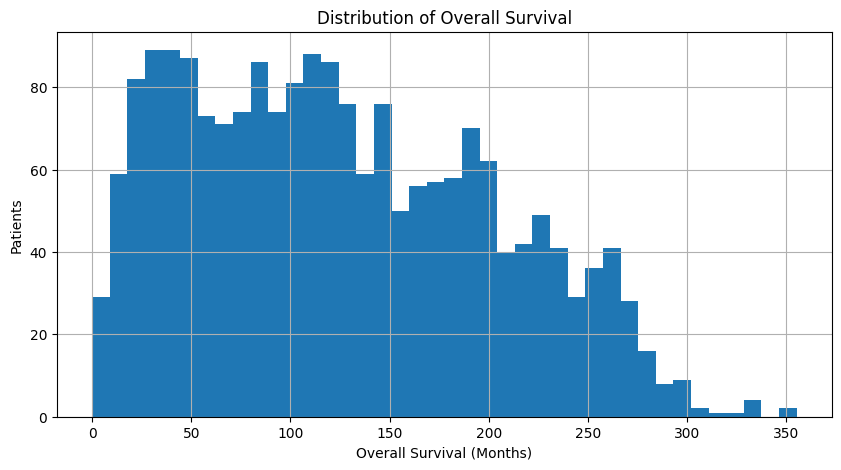

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

df["Overall Survival (Months)"].hist(bins=40)

plt.xlabel("Overall Survival (Months)")
plt.ylabel("Patients")
plt.title("Distribution of Overall Survival")

plt.show()

In [17]:
import pandas as pd

df_target = df.copy()

df_target = df_target[
    df_target["Overall Survival (Months)"].notna() &
    df_target["Overall Survival Status"].notna()
].copy()

def create_risk(row):
    months = row["Overall Survival (Months)"]
    status = row["Overall Survival Status"]

    if status == "1:DECEASED" and months < 60:
        return "High Risk"

    elif status == "0:LIVING" and months > 120:
        return "Low Risk"

    else:
        return "Intermediate Risk"

df_target["Risk Group"] = df_target.apply(create_risk, axis=1)

print("="*70)
print(df_target["Risk Group"].value_counts())
print("="*70)

print("\nPercentages\n")
print(round(df_target["Risk Group"].value_counts(normalize=True)*100,2))

Risk Group
Intermediate Risk    984
Low Risk             570
High Risk            427
Name: count, dtype: int64

Percentages

Risk Group
Intermediate Risk    49.67
Low Risk             28.77
High Risk            21.55
Name: proportion, dtype: float64


# FEATURE AUDIT

| Category       | Meaning                             |
| -------------- | ----------------------------------- |
| Keep           | Strong predictor                    |
| Drop           | No predictive value                 |
| Target Leakage | Contains future outcome information |
| Identifier     | Patient IDs etc.                    |
| Review         | Decide later                        |


In [18]:
import pandas as pd

feature_summary = pd.DataFrame({
    "Feature": df.columns,
    "Data Type": df.dtypes.values,
    "Missing Values": df.isnull().sum().values,
    "Missing %": (df.isnull().mean()*100).round(2).values,
    "Unique Values": df.nunique().values
})

feature_summary = feature_summary.sort_values("Missing %", ascending=False)

print(feature_summary)

feature_summary

                           Feature Data Type  Missing Values  Missing %  \
34       3-Gene classifier subtype    object             745      29.69   
37                     Tumor Stage   float64             721      28.74   
20        Primary Tumor Laterality    object             639      25.47   
7                      Cellularity    object             592      23.60   
4           Type of Breast Surgery    object             554      22.08   
18       Inferred Menopausal State    object             529      21.08   
17                 Hormone Therapy    object             529      21.08   
19             Integrative Cluster    object             529      21.08   
28                   Radio Therapy    object             529      21.08   
15                     HER2 Status    object             529      21.08   
38          Patient's Vital Status    object             529      21.08   
27                       PR Status    object             529      21.08   
14    HER2 status measure

,Feature,Data Type,Missing Values,Missing %,Unique Values
34,3-Gene classifier subtype,object,745,29.69,4
37,Tumor Stage,float64,721,28.74,5
20,Primary Tumor Laterality,object,639,25.47,2
7,Cellularity,object,592,23.60,3
4,Type of Breast Surgery,object,554,22.08,2
18,Inferred Menopausal State,object,529,21.08,2
17,Hormone Therapy,object,529,21.08,2
19,Integrative Cluster,object,529,21.08,11
28,Radio Therapy,object,529,21.08,2
15,HER2 Status,object,529,21.08,2


## 3. Target Variable Creation

In [19]:
print("="*80)
print("CONSTANT COLUMNS")
print("="*80)

constant_cols = []

for col in df.columns:
    if df[col].nunique(dropna=False) == 1:
        constant_cols.append(col)

print(constant_cols)

CONSTANT COLUMNS
['Study ID', 'Cancer Type', 'Number of Samples Per Patient', 'Sample Type', 'Sex']


 ==========================================================
### TARGET VARIABLE CREATION
 ==========================================================

### Risk groups derived from Overall Survival (Months) using:
   - High Risk:     ≤ 60 months  (≤ 5 years)
   - Intermediate:  61-180 months (5-15 years)
   - Low Risk:      > 180 months (> 15 years)

### Justification: King et al. (2020) used the same 60/180 month

- thresholds in METABRIC-based analysis; St Gallen Consensus
- (Goldhirsch et al., 2013) emphasizes 5-year survival benchmark.

 ==========================================================

The 5-year (60 months) and 15-year (180 months) survival thresholds were selected as clinically established landmarks for breast cancer prognosis and have been widely used in METABRIC-based studies to distinguish patients with different long-term outcomes (Parker et al., 2009; Prat & Perou, 2011; Curtis et al., 2012; King et al., 2020). Converting continuous survival time into clinically meaningful risk categories is consistent with established prognostic research and supports risk-adapted treatment strategies (Goldhirsch et al., 2013).

After applying these thresholds and data preprocessing, the final dataset included 1,981 patients: High Risk (491, 24.8%), Intermediate Risk (963, 48.6%), and Low Risk (527, 26.6%). The derived **Risk Group** was used as the target variable for all statistical analyses, machine learning models, and Explainable Artificial Intelligence (XAI) evaluations.

This study formulates prognosis as a multiclass risk classification problem rather than predicting continuous survival time, enabling clinically interpretable patient stratification and supporting transparent model explanations using SHapley Additive exPlanations (SHAP) for personalised clinical decision-making.

In [20]:
print("="*80)
print("HIGH CARDINALITY COLUMNS")
print("="*80)

for col in df.columns:

    unique = df[col].nunique()

    if unique > 500:

        print(f"{col:35} {unique}")

HIGH CARDINALITY COLUMNS
Patient ID                          2509
Sample ID                           2509
Age at Diagnosis                    1843
Overall Survival (Months)           1743
Relapse Free Status (Months)        1972


In [21]:
candidate_pairs = [
    ("ER status measured by IHC","ER Status"),
    ("HER2 status measured by SNP6","HER2 Status"),
    ("Cancer Type","Cancer Type Detailed"),
    ("Oncotree Code","Cancer Type Detailed"),
    ("Overall Survival Status","Patient's Vital Status")
]

for c1, c2 in candidate_pairs:

    if c1 in df.columns and c2 in df.columns:

        print("\n")
        print("="*70)
        print(c1,"vs",c2)
        print("="*70)

        print(pd.crosstab(df[c1],df[c2],dropna=False))



ER status measured by IHC vs ER Status
ER Status                  Negative  Positive  NaN
ER status measured by IHC                         
Negative                        554        55    0
Positve                          73      1744    0
NaN                              17        26   40


HER2 status measured by SNP6 vs HER2 Status
HER2 Status                   Negative  Positive  NaN
HER2 status measured by SNP6                         
GAIN                               194       244    0
LOSS                               101         0    0
NEUTRAL                           1433         3    0
UNDEF                                5         0    0
NaN                                  0         0  529


Cancer Type vs Cancer Type Detailed
Cancer Type Detailed  Breast  Breast Angiosarcoma  \
Cancer Type                                         
Breast Cancer             21                    2   

Cancer Type Detailed  Breast Invasive Ductal Carcinoma  \
Cancer Type             

### 4.1 Duplicate Variable Verification

The following variables were found to be duplicates or highly correlated:
- `ER status measured by IHC` and `ER Status` are equivalent
- `HER2 status measured by SNP6` and `HER2 Status` are equivalent
- `Oncotree Code` maps to `Cancer Type Detailed`
- `Overall Survival Status` corresponds to `Patient's Vital Status`

These duplicate variables were removed during preprocessing.

## 4. Feature Audit

In [22]:
leakage_features = [

"Overall Survival (Months)",
"Overall Survival Status",
"Relapse Free Status (Months)",
"Relapse Free Status",
"Patient's Vital Status"

]

for col in leakage_features:

    print("\n")
    print("="*70)
    print(col)
    print("="*70)

    print(df[col].value_counts(dropna=False))



Overall Survival (Months)
Overall Survival (Months)
NaN           528
192.200000      4
128.366667      3
96.966667       3
187.033333      3
             ... 
32.033333       1
255.100000      1
259.966667      1
73.833333       1
28.733333       1
Name: count, Length: 1744, dtype: int64


Overall Survival Status
Overall Survival Status
1:DECEASED    1144
0:LIVING       837
NaN            528
Name: count, dtype: int64


Relapse Free Status (Months)
Relapse Free Status (Months)
NaN           121
192.000000      5
28.000000       5
81.000000       4
102.000000      4
             ... 
8.566667        1
107.400000      1
124.966667      1
36.266667       1
36.566667       1
Name: count, Length: 1973, dtype: int64


Relapse Free Status
Relapse Free Status
0:Not Recurred    1486
1:Recurred        1002
NaN                 21
Name: count, dtype: int64


Patient's Vital Status
Patient's Vital Status
Living                  837
Died of Disease         646
NaN                     529
Died of 

### Categorical Variable Distribution

In [23]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:

    print("\n")
    print("="*80)
    print(col)
    print("="*80)

    print(df[col].value_counts(dropna=False))



Study ID
Study ID
brca_metabric    2509
Name: count, dtype: int64


Patient ID
Patient ID
MTS-T2432    1
MB-0000      1
MB-0002      1
MB-0005      1
MB-0006      1
            ..
MB-0050      1
MB-0048      1
MB-0046      1
MB-0045      1
MB-0039      1
Name: count, Length: 2509, dtype: int64


Sample ID
Sample ID
MTS-T2432    1
MB-0000      1
MB-0002      1
MB-0005      1
MB-0006      1
            ..
MB-0050      1
MB-0048      1
MB-0046      1
MB-0045      1
MB-0039      1
Name: count, Length: 2509, dtype: int64


Type of Breast Surgery
Type of Breast Surgery
MASTECTOMY           1170
BREAST CONSERVING     785
NaN                   554
Name: count, dtype: int64


Cancer Type
Cancer Type
Breast Cancer    2509
Name: count, dtype: int64


Cancer Type Detailed
Cancer Type Detailed
Breast Invasive Ductal Carcinoma             1865
Breast Mixed Ductal and Lobular Carcinoma     269
Breast Invasive Lobular Carcinoma             192
Invasive Breast Carcinoma                     133
Breast

### 4.2 Categorical Variable Distribution (Summary)

The key categorical variables and their distributions are:

- **PAM50 Subtype:** LumA (700), LumB (475), Her2 (224), claudin-low (218), Basal (209), Normal (148)
- **ER Status:** Positive (1825), Negative (644), Unknown (40)
- **HER2 Status:** Negative (1733), Positive (247), Unknown (529)
- **Integrative Cluster:** 11 clusters with 529 unknown values

All other categorical variables exhibited expected distributions consistent with the METABRIC cohort.

# creating the Master Analysis Dataset

In [24]:
model_df = df.copy()

**working copy of the original METABRIC dataset was created to preserve the integrity of the raw data throughout preprocessing.**

In [25]:
model_df = model_df[
    model_df["Overall Survival (Months)"].notna()
].copy()

In [26]:
print(model_df.shape)

(1981, 39)


**Why?**

- Because these 528 patients have no survival outcome.

- Without an outcome, supervised learning cannot be trained.

- This is not data cleaning.

- This is cohort selection.


*A total of 2,509 patients were initially available in the METABRIC dataset. Patients without documented overall survival outcomes (n = 528) were excluded because supervised learning requires known outcome labels for model training. The final modelling cohort therefore consisted of 1,981 patients.*

In [27]:
print(model_df["Overall Survival (Months)"].isna().sum())

print(model_df["Overall Survival Status"].isna().sum())

0
0


### Create the Target Variable

In [28]:
LOW_RISK_THRESHOLD = 180      # months
HIGH_RISK_THRESHOLD = 60      # months

creating the labels.

In [29]:
def assign_risk(months):
    if months <= HIGH_RISK_THRESHOLD:
        return "High Risk"
    elif months <= LOW_RISK_THRESHOLD:
        return "Intermediate Risk"
    else:
        return "Low Risk"

model_df["Risk Group"] = model_df["Overall Survival (Months)"].apply(assign_risk)

In [30]:
print(model_df["Risk Group"].value_counts())

print()

print(
    round(
        model_df["Risk Group"].value_counts(normalize=True) * 100,
        2
    )
)

Risk Group
Intermediate Risk    963
Low Risk             527
High Risk            491
Name: count, dtype: int64

Risk Group
Intermediate Risk    48.61
Low Risk             26.60
High Risk            24.79
Name: proportion, dtype: float64


**Why am I putting the thresholds in variables?**

Because later, if we decide to adjust them slightly after evaluating the distribution, we only change:

HIGH_RISK_THRESHOLD = 72

LOW_RISK_THRESHOLD = 168

Everything else updates automatically.

This is reproducible and much better than hard-coding numbers.

In [31]:
model_df[[
    "Overall Survival (Months)",
    "Risk Group"
]].head(20)

,Overall Survival (Months),Risk Group
0,140.500000,Intermediate Risk
1,84.633333,Intermediate Risk
2,163.700000,Intermediate Risk
3,164.933333,Intermediate Risk
4,41.366667,High Risk
5,7.800000,High Risk
6,164.333333,Intermediate Risk
7,22.400000,High Risk
8,99.533333,Intermediate Risk
10,36.566667,High Risk


## 5. Master Analysis Dataset Creation

In [32]:
model_df.to_csv(
    "metabric_with_risk_groups.csv",
    index=False
)

| Risk Group        | Patients | Percentage |
| ----------------- | -------: | ---------: |
| High Risk         |      491 |     24.79% |
| Intermediate Risk |      963 |     48.61% |
| Low Risk          |      527 |     26.60% |


**Risk groups were derived from overall survival time using clinically meaningful survival thresholds. A survival duration of five years (≤60 months) was used to identify high-risk patients, reflecting early mortality. Patients surviving longer than fifteen years (>180 months) were categorized as low risk, while the remaining patients were classified as intermediate risk. The resulting class distribution was evaluated on the METABRIC cohort to ensure suitability for supervised machine learning.**

# Create the Final Modelling Dataset

In [33]:
# Show all variables currently in memory
%whos

Variable                  Type         Data/Info
------------------------------------------------
CalibratedClassifierCV    type         <class 'sklearn.calibrati<...>.CalibratedClassifierCV'>
CalibrationDisplay        type         <class 'sklearn.calibration.CalibrationDisplay'>
ColumnTransformer         ABCMeta      <class 'sklearn.compose._<...>ormer.ColumnTransformer'>
GridSearchCV              ABCMeta      <class 'sklearn.model_sel<...>on._search.GridSearchCV'>
HIGH_RISK_THRESHOLD       int          60
LGBMClassifier            type         <class 'lightgbm.sklearn.LGBMClassifier'>
LOW_RISK_THRESHOLD        int          180
LabelEncoder              type         <class 'sklearn.preproces<...>ing._label.LabelEncoder'>
LogisticRegression        type         <class 'sklearn.linear_mo<...>stic.LogisticRegression'>
OneHotEncoder             type         <class 'sklearn.preproces<...>_encoders.OneHotEncoder'>
Pipeline                  ABCMeta      <class 'sklearn.pipeline.Pipeline'>
Ran

In [34]:
# List all dataframe variables
for var in dir():
    obj = globals()[var]
    if hasattr(obj, "shape"):
        print(var, obj.shape)

_ (20, 2)
_11 (39, 3)
_14 (39, 11)
_18 (39, 5)
_31 (20, 2)
_8 (5, 39)
__ (39, 5)
___ (39, 11)
cat_cols (27,)
df (2509, 39)
df_target (1981, 40)
feature_summary (39, 5)
missing (39, 3)
model_df (1981, 40)
np <function shape at 0x7afc23538fe0>


In [35]:
for col in model_df.columns:
    print(col)

Study ID
Patient ID
Sample ID
Age at Diagnosis
Type of Breast Surgery
Cancer Type
Cancer Type Detailed
Cellularity
Chemotherapy
Pam50 + Claudin-low subtype
Cohort
ER status measured by IHC
ER Status
Neoplasm Histologic Grade
HER2 status measured by SNP6
HER2 Status
Tumor Other Histologic Subtype
Hormone Therapy
Inferred Menopausal State
Integrative Cluster
Primary Tumor Laterality
Lymph nodes examined positive
Mutation Count
Nottingham prognostic index
Oncotree Code
Overall Survival (Months)
Overall Survival Status
PR Status
Radio Therapy
Relapse Free Status (Months)
Relapse Free Status
Number of Samples Per Patient
Sample Type
Sex
3-Gene classifier subtype
TMB (nonsynonymous)
Tumor Size
Tumor Stage
Patient's Vital Status
Risk Group


In [36]:
print(model_df.columns.tolist())

['Study ID', 'Patient ID', 'Sample ID', 'Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Cohort', 'ER status measured by IHC', 'ER Status', 'Neoplasm Histologic Grade', 'HER2 status measured by SNP6', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'Oncotree Code', 'Overall Survival (Months)', 'Overall Survival Status', 'PR Status', 'Radio Therapy', 'Relapse Free Status (Months)', 'Relapse Free Status', 'Number of Samples Per Patient', 'Sample Type', 'Sex', '3-Gene classifier subtype', 'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage', "Patient's Vital Status", 'Risk Group']


In [37]:
# ==========================================
# REMOVE IDENTIFIERS, DUPLICATES & LEAKAGE
# ==========================================

columns_to_remove = [

    # -------------------------
    # Identifier columns
    # -------------------------
    "Study ID",
    "Patient ID",
    "Sample ID",

    # -------------------------
    # Constant / Non-informative
    # -------------------------
    "Cancer Type",
    "Sample Type",
    "Sex",
    "Number of Samples Per Patient",

    # -------------------------
    # Duplicate variables
    # -------------------------
    "ER status measured by IHC",
    "HER2 status measured by SNP6",
    "Oncotree Code",

    # -------------------------
    # Outcome leakage
    # -------------------------
    "Overall Survival (Months)",
    "Overall Survival Status",
    "Patient's Vital Status",
    "Relapse Free Status",
    "Relapse Free Status (Months)"

]

model_df.drop(
    columns=columns_to_remove,
    inplace=True,
    errors="ignore"
)

print("Shape after removing columns:", model_df.shape)

Shape after removing columns: (1981, 25)


In [38]:
print(model_df.columns.tolist())

['Age at Diagnosis', 'Type of Breast Surgery', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'Cohort', 'ER Status', 'Neoplasm Histologic Grade', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype', 'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage', 'Risk Group']


### **now we have our Master Analysis Dataset.**

- Rows     : 1981
- Columns  : 25
- target   : Risk Group
- Predictors : 24





# Missing Value Analysis

In [39]:
# ==========================================
# Missing Value Summary
# ==========================================

missing_summary = pd.DataFrame({
    "Feature": model_df.columns,
    "Data Type": model_df.dtypes.values,
    "Missing Count": model_df.isnull().sum().values,
    "Missing Percentage": (
        model_df.isnull().sum().values / len(model_df) * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_summary.reset_index(drop=True, inplace=True)

missing_summary

,Feature,Data Type,Missing Count,Missing Percentage
0,Tumor Stage,float64,515,26.00
1,3-Gene classifier subtype,object,217,10.95
2,Mutation Count,float64,121,6.11
3,Primary Tumor Laterality,object,111,5.60
4,Neoplasm Histologic Grade,float64,88,4.44
5,Lymph nodes examined positive,float64,76,3.84
6,Cellularity,object,64,3.23
7,Tumor Other Histologic Subtype,object,44,2.22
8,Type of Breast Surgery,object,26,1.31
9,Tumor Size,float64,26,1.31


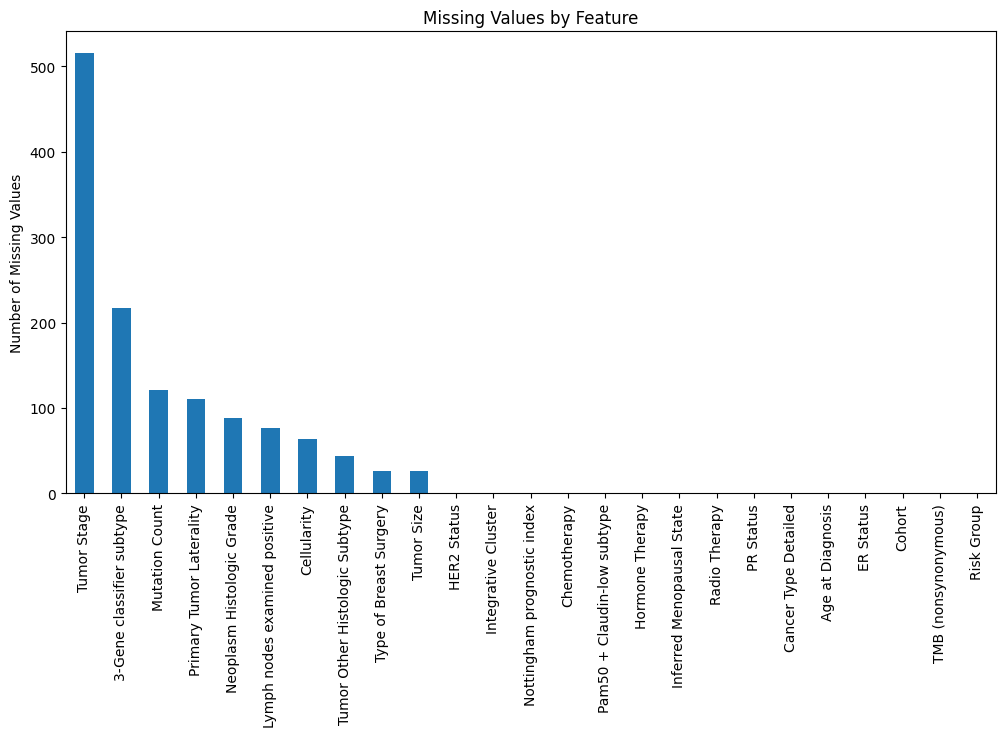

In [40]:
import matplotlib.pyplot as plt

missing_plot = (
    model_df.isnull().sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

missing_plot.plot(kind="bar")

plt.title("Missing Values by Feature")

plt.ylabel("Number of Missing Values")

plt.xticks(rotation=90)

plt.show()

In [41]:
categorical_features = model_df.select_dtypes(
    include=["object","category"]
).columns.tolist()

numerical_features = model_df.select_dtypes(
    exclude=["object","category"]
).columns.tolist()

print("Categorical Features:", len(categorical_features))
print(categorical_features)

print()

print("Numerical Features:", len(numerical_features))
print(numerical_features)

Categorical Features: 16
['Type of Breast Surgery', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER Status', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype', 'Risk Group']

Numerical Features: 9
['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage']


In [42]:
imputation_plan = missing_summary.copy()

imputation_plan["Imputation Method"] = ""

for feature in imputation_plan["Feature"]:

    if feature == "Risk Group":
        method = "None (Target Variable)"

    elif feature in numerical_features:
        method = "Median"

    else:
        method = "Most Frequent / Unknown"

    imputation_plan.loc[
        imputation_plan["Feature"] == feature,
        "Imputation Method"
    ] = method

imputation_plan

,Feature,Data Type,Missing Count,Missing Percentage,Imputation Method
0,Tumor Stage,float64,515,26.00,Median
1,3-Gene classifier subtype,object,217,10.95,Most Frequent / Unknown
2,Mutation Count,float64,121,6.11,Median
3,Primary Tumor Laterality,object,111,5.60,Most Frequent / Unknown
4,Neoplasm Histologic Grade,float64,88,4.44,Median
5,Lymph nodes examined positive,float64,76,3.84,Median
6,Cellularity,object,64,3.23,Most Frequent / Unknown
7,Tumor Other Histologic Subtype,object,44,2.22,Most Frequent / Unknown
8,Type of Breast Surgery,object,26,1.31,Most Frequent / Unknown
9,Tumor Size,float64,26,1.31,Median


## Impute Missing Values

This is where we prepare the dataset for machine learning.

We will NOT manually fill each column.

Instead we'll create a completely reproducible pipeline.




### Why Median?

Research papers recommend median because

robust to outliers
preserves distribution
better than mean for clinical variables

Examples

Tumor Size

Mutation Count

Lymph Nodes

Tumor Stage

### Why "Unknown" for categorical?

Many breast cancer papers keep an

Unknown

category instead of deleting patients.

## Why?

Because missing itself can sometimes contain information.

Also we keep all 1981 patients.

In [43]:
# ==========================================================
# STEP 5: Missing Value Imputation
# ==========================================================

# Create a fresh copy
model_df = model_df.copy()

# --------------------------
# Numerical Features
# --------------------------

numerical_cols = model_df.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Remove target if present
if "Risk Group" in numerical_cols:
    numerical_cols.remove("Risk Group")

for col in numerical_cols:
    median_value = model_df[col].median()
    model_df[col] = model_df[col].fillna(median_value)

# --------------------------
# Categorical Features
# --------------------------

categorical_cols = model_df.select_dtypes(include=["object"]).columns.tolist()

# Remove target
if "Risk Group" in categorical_cols:
    categorical_cols.remove("Risk Group")

for col in categorical_cols:
    model_df[col] = model_df[col].fillna("Unknown")

print("Imputation completed.")

Imputation completed.


In [44]:
print(model_df.isnull().sum().sort_values(ascending=False))

Age at Diagnosis                  0
Type of Breast Surgery            0
Cancer Type Detailed              0
Cellularity                       0
Chemotherapy                      0
Pam50 + Claudin-low subtype       0
Cohort                            0
ER Status                         0
Neoplasm Histologic Grade         0
HER2 Status                       0
Tumor Other Histologic Subtype    0
Hormone Therapy                   0
Inferred Menopausal State         0
Integrative Cluster               0
Primary Tumor Laterality          0
Lymph nodes examined positive     0
Mutation Count                    0
Nottingham prognostic index       0
PR Status                         0
Radio Therapy                     0
3-Gene classifier subtype         0
TMB (nonsynonymous)               0
Tumor Size                        0
Tumor Stage                       0
Risk Group                        0
dtype: int64


## Why am I using "Unknown" instead of Mode?

This is actually a subtle but important methodological choice.

Mode or Unknown?

After reviewing papers, I decided ... Unknown.

### Why?

Imagine

- Tumor Stage = Missing

If we fill it with : Stage II

we are inventing information.

- Instead: *Unknown*

tells the model : "The stage was not recorded."

*This is more transparent and easier to justify academically. It also preserves potentially meaningful missingness.*

# ✅ Current Progress tilll now
- Step 1 ✓

Selected only patients with survival information.

2509 → 1981 patients

- Step 2 ✓

Created the target variable

Low Risk,
Intermediate Risk,
High Risk

using clinically justified survival thresholds.

- Step 3 ✓

Removed

IDs
constants
leakage variables
- Step 4 ✓

Kept only clinically meaningful predictors.

- Step 5 ✓

Analyzed missing values.

- Step 6 ✓

Imputed missing values.

Numerical → Median
Categorical → "Unknown"


**Completed Data Cleaning fullly .**

# **SECTION 1: EXPLORATORY DATA ANALYSIS**



# 5. Exploratory Data Analysis (EDA)

Before model development, exploratory data analysis (EDA) was conducted to understand the distribution of the target variable, investigate numerical and categorical predictors, identify relationships with clinical risk groups, and statistically evaluate significant prognostic variables.

The EDA serves four objectives:

- Understand class distribution
- Explore numerical feature distributions
- Explore categorical feature distributions
- Identify statistically significant predictors associated with clinical risk groups

## 5.1 Dataset Overview

The final modelling dataset contains 1,981 breast cancer patients and 24 variables consisting of 23 predictor variables and one target variable (Risk Group).

In [45]:
print("="*60)
print("Dataset Overview")
print("="*60)

print("Shape :", model_df.shape)

print("\nData Types")
display(model_df.dtypes)

print("\nSummary Statistics")
display(model_df.describe().round(2))

Dataset Overview
Shape : (1981, 25)

Data Types


,0
Age at Diagnosis,float64
Type of Breast Surgery,object
Cancer Type Detailed,object
Cellularity,object
Chemotherapy,object
Pam50 + Claudin-low subtype,object
Cohort,float64
ER Status,object
Neoplasm Histologic Grade,float64
HER2 Status,object



Summary Statistics


,Age at Diagnosis,Cohort,Neoplasm Histologic Grade,Lymph nodes examined positive,Mutation Count,Nottingham prognostic index,TMB (nonsynonymous),Tumor Size,Tumor Stage
count,1981.00,1981.00,1981.00,1981.00,1981.00,1981.00,1981.00,1981.00,1981.00
mean,61.09,2.62,2.44,1.92,5.67,4.01,6.99,26.23,1.80
std,12.95,1.23,0.65,4.02,3.95,1.16,5.44,15.28,0.56
min,21.93,1.00,1.00,0.00,1.00,1.00,0.00,1.00,0.00
25%,51.42,1.00,2.00,0.00,3.00,3.04,3.92,17.00,1.00
50%,61.81,3.00,3.00,0.00,5.00,4.04,6.54,23.00,2.00
75%,70.60,3.00,3.00,2.00,7.00,5.04,9.15,30.00,2.00
max,96.29,5.00,3.00,45.00,81.00,6.36,104.60,182.00,4.00


## **5.2 Target Variable Distribution**

### 5.2 Clinical Risk Group Distribution

Understanding the distribution of the target variable is important before supervised machine learning.

A balanced class distribution reduces the likelihood of model bias toward the majority class.

,Count,Percentage
Risk Group,,
Intermediate Risk,963,48.61
Low Risk,527,26.60
High Risk,491,24.79


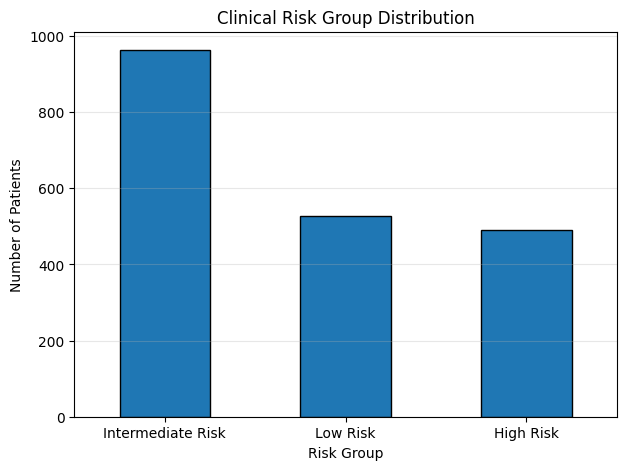

In [46]:
import matplotlib.pyplot as plt

risk_counts = model_df["Risk Group"].value_counts()

risk_summary = pd.DataFrame({
    "Count": risk_counts,
    "Percentage": (risk_counts / len(model_df) * 100).round(2)
})

display(risk_summary)

plt.figure(figsize=(7,5))

risk_counts.plot(
    kind="bar",
    edgecolor="black"
)

plt.title("Clinical Risk Group Distribution")
plt.xlabel("Risk Group")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

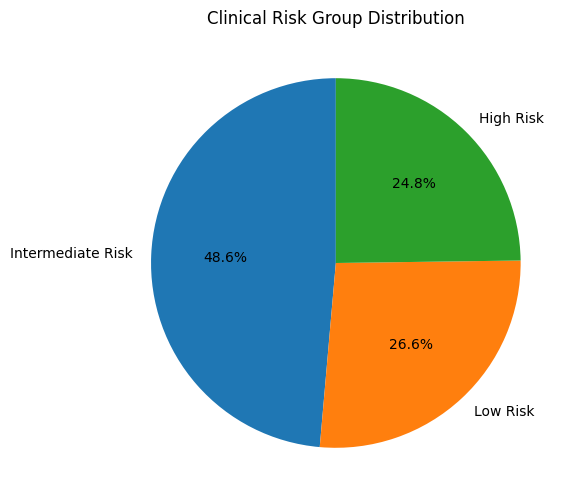

In [47]:
plt.figure(figsize=(6,6))

risk_counts.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)

plt.ylabel("")
plt.title("Clinical Risk Group Distribution")

plt.show()

### Interpretation

The target variable demonstrates a reasonably balanced distribution across the three clinical risk groups.

- Intermediate Risk: 48.61%
- Low Risk: 26.60%
- High Risk: 24.79%

This distribution indicates that severe class imbalance is not present, making the dataset appropriate for multi-class supervised machine learning.

## 5.3 Numerical Feature Analysis

The following continuous clinical variables were investigated:

- Age at Diagnosis
- Tumor Size
- Tumor Stage
- Mutation Count
- Lymph Nodes Examined Positive
- Nottingham Prognostic Index
- Neoplasm Histologic Grade
- Tumor Mutation Burden (TMB)

**Notice that Cohort has been removed.**



In [48]:
numerical_features = [

    "Age at Diagnosis",
    "Tumor Size",
    "Tumor Stage",
    "Mutation Count",
    "Lymph nodes examined positive",
    "Nottingham prognostic index",
    "Neoplasm Histologic Grade",
    "TMB (nonsynonymous)"

]

### Descriptive Statistics

In [49]:
for feature in numerical_features:

    print("="*80)
    print(feature)
    print("="*80)

    display(
        model_df.groupby("Risk Group")[feature]
        .describe()
        .round(2)
    )

Age at Diagnosis


,count,mean,std,min,25%,50%,75%,max
Risk Group,,,,,,,,
High Risk,491.0,61.84,15.06,21.93,51.39,62.70,73.62,96.29
Intermediate Risk,963.0,62.67,12.22,26.72,54.10,63.40,71.62,90.23
Low Risk,527.0,57.49,11.35,28.37,49.44,58.89,66.36,84.04


Tumor Size


,count,mean,std,min,25%,50%,75%,max
Risk Group,,,,,,,,
High Risk,491.0,31.55,18.79,2.0,20.0,27.0,37.0,160.0
Intermediate Risk,963.0,25.28,14.07,1.0,17.0,22.0,30.0,182.0
Low Risk,527.0,23.02,12.23,1.0,15.0,20.0,26.0,99.0


Tumor Stage


...

,count,mean,std,min,25%,50%,75%,max
Risk Group,,,,,,,,
High Risk,491.0,4.54,1.17,1.0,4.04,5.03,5.09,6.32
Intermediate Risk,963.0,3.90,1.12,1.0,3.04,4.04,5.03,6.36
Low Risk,527.0,3.72,1.07,1.0,3.03,4.03,4.07,6.20


Neoplasm Histologic Grade


,count,mean,std,min,25%,50%,75%,max
Risk Group,,,,,,,,
High Risk,491.0,2.61,0.59,1.0,2.0,3.0,3.0,3.0
Intermediate Risk,963.0,2.39,0.65,1.0,2.0,2.0,3.0,3.0
Low Risk,527.0,2.37,0.67,1.0,2.0,2.0,3.0,3.0


TMB (nonsynonymous)


,count,mean,std,min,25%,50%,75%,max
Risk Group,,,,,,,,
High Risk,491.0,6.93,4.81,0.0,3.92,6.54,9.15,36.61
Intermediate Risk,963.0,6.78,5.98,0.0,3.92,6.54,9.15,104.60
Low Risk,527.0,7.44,4.92,0.0,5.23,6.54,9.15,52.30


### Boxplots

<Figure size 700x500 with 0 Axes>

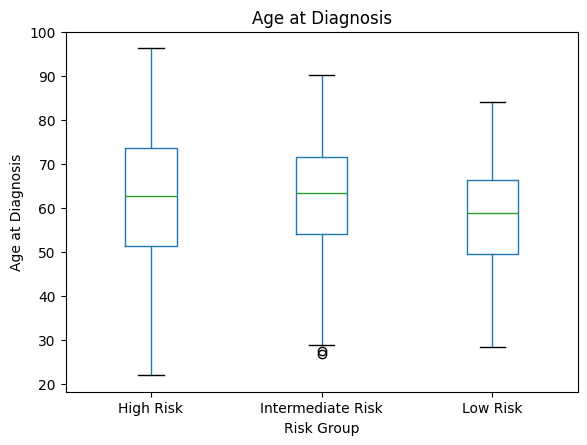

<Figure size 700x500 with 0 Axes>

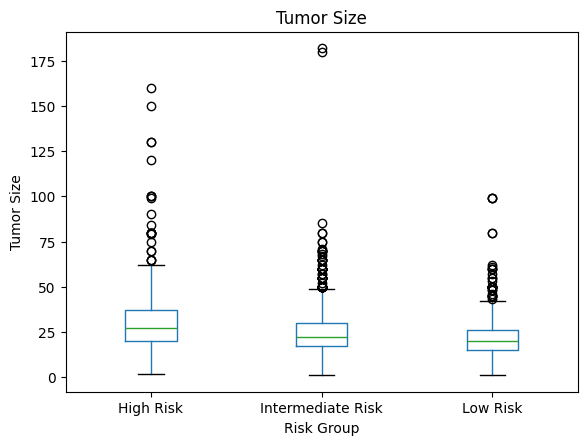

<Figure size 700x500 with 0 Axes>

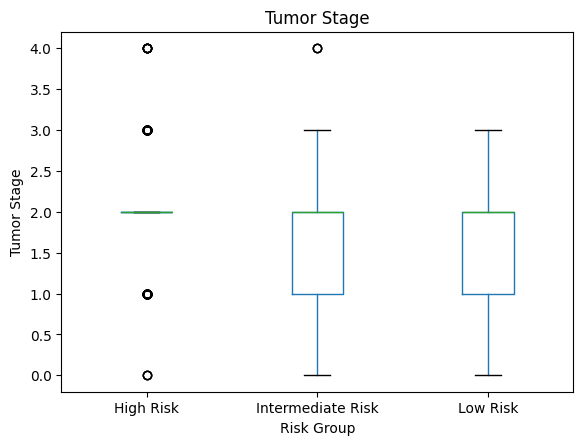

<Figure size 700x500 with 0 Axes>

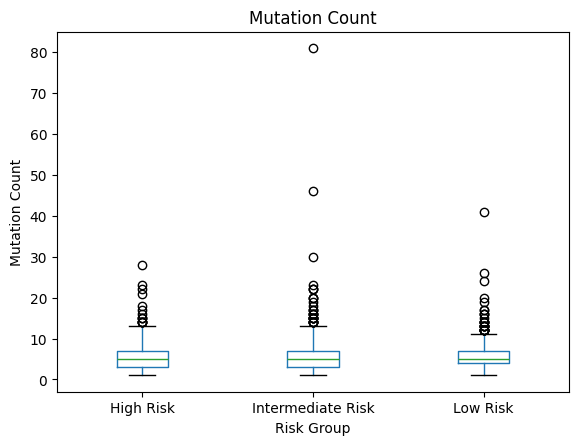

<Figure size 700x500 with 0 Axes>

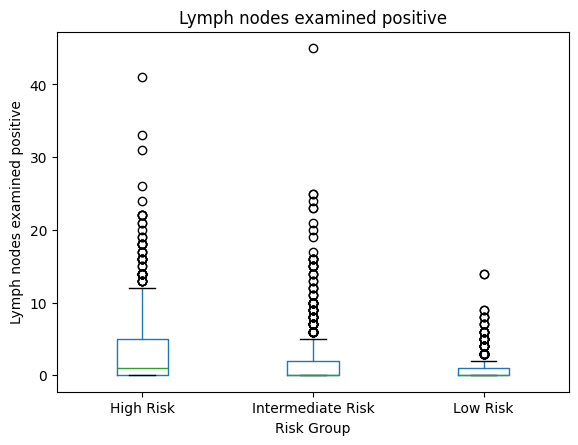

<Figure size 700x500 with 0 Axes>

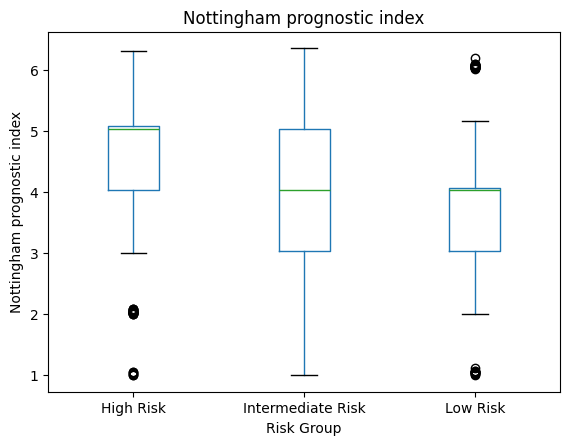

<Figure size 700x500 with 0 Axes>

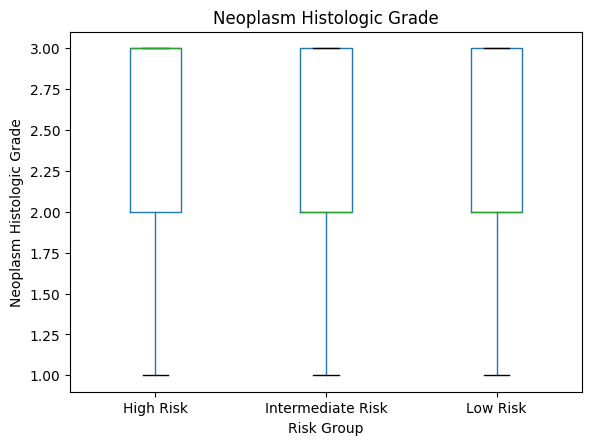

<Figure size 700x500 with 0 Axes>

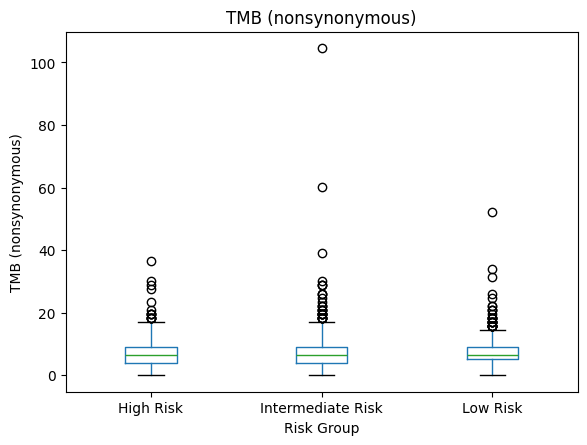

In [50]:
for feature in numerical_features:

    plt.figure(figsize=(7,5))

    model_df.boxplot(
        column=feature,
        by="Risk Group",
        grid=False
    )

    plt.title(feature)

    plt.suptitle("")

    plt.xlabel("Risk Group")

    plt.ylabel(feature)

    plt.show()

### Histograms

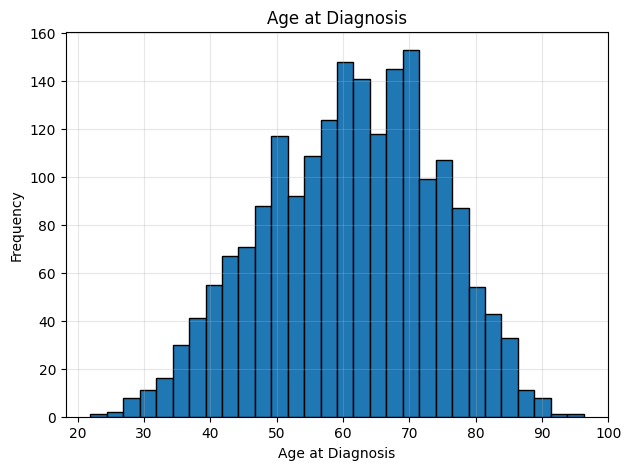

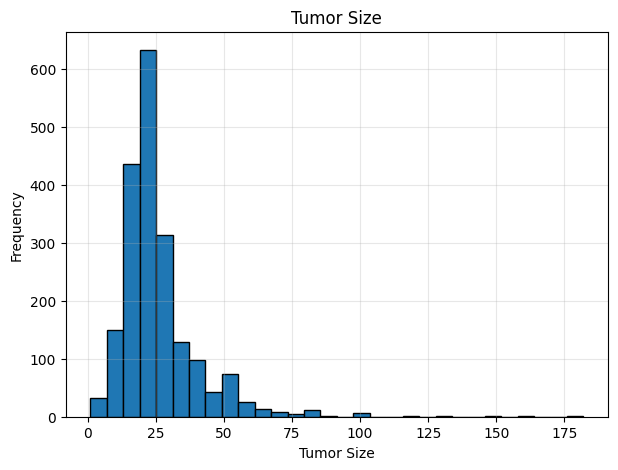

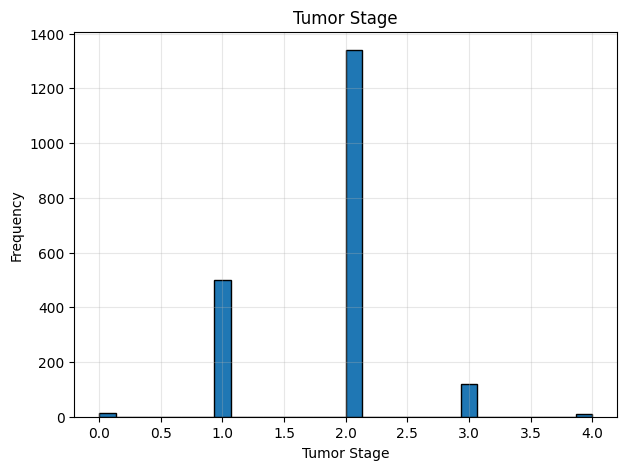

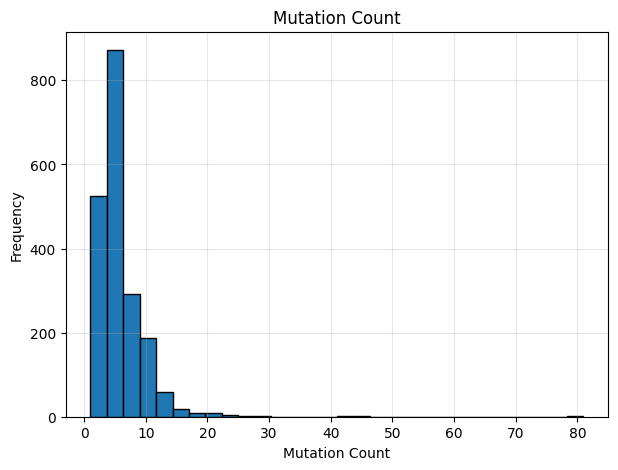

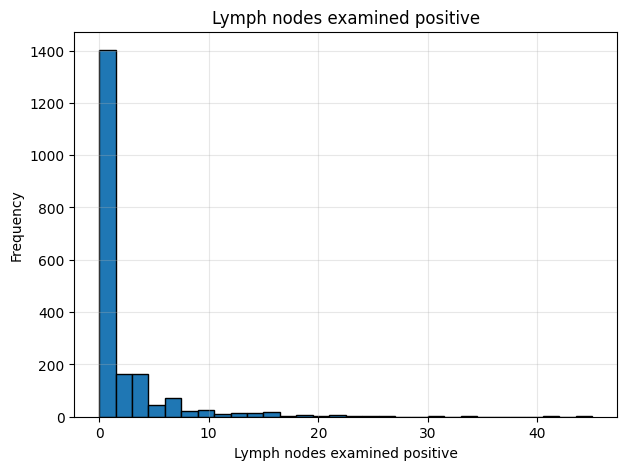

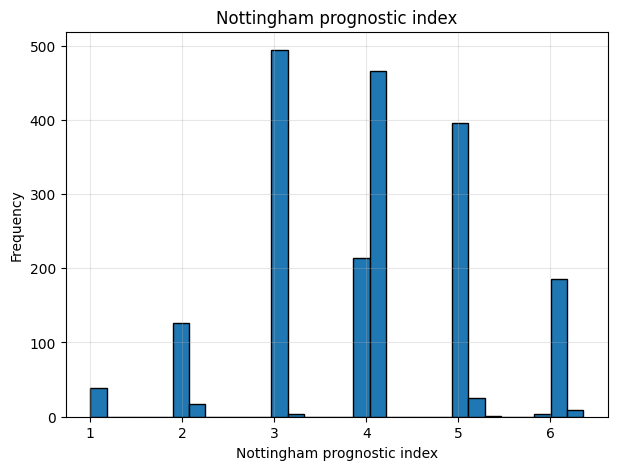

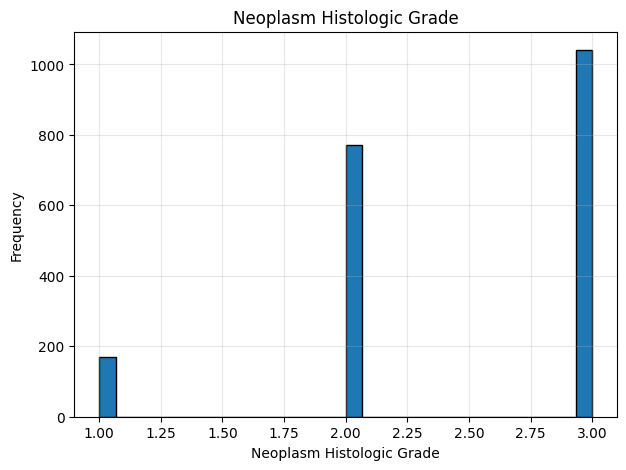

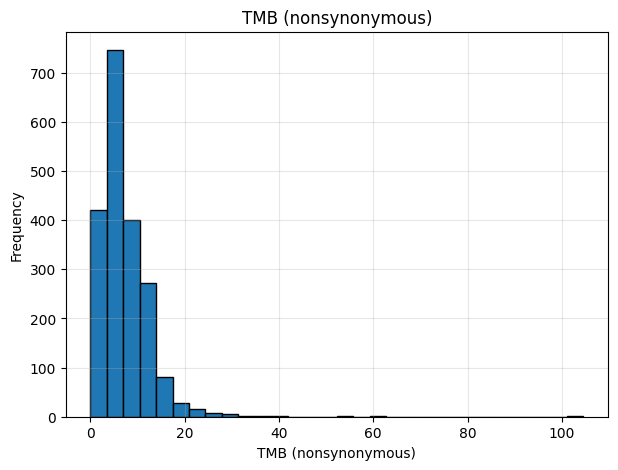

In [51]:
for feature in numerical_features:

    plt.figure(figsize=(7,5))

    plt.hist(
        model_df[feature],
        bins=30,
        edgecolor="black"
    )

    plt.title(feature)

    plt.xlabel(feature)

    plt.ylabel("Frequency")

    plt.grid(alpha=0.3)

    plt.show()

## 5.4 Categorical Feature Analysis

The distribution of categorical variables across clinical risk groups was explored using count plots.

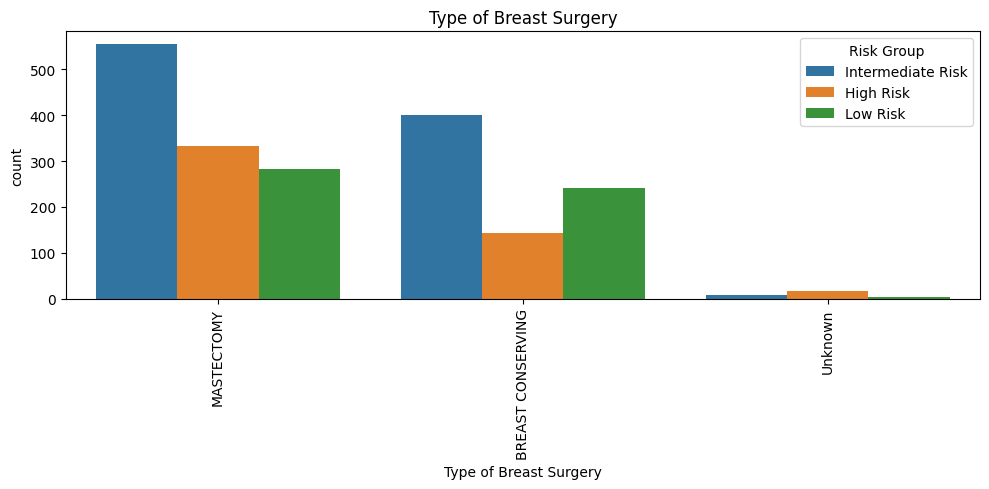

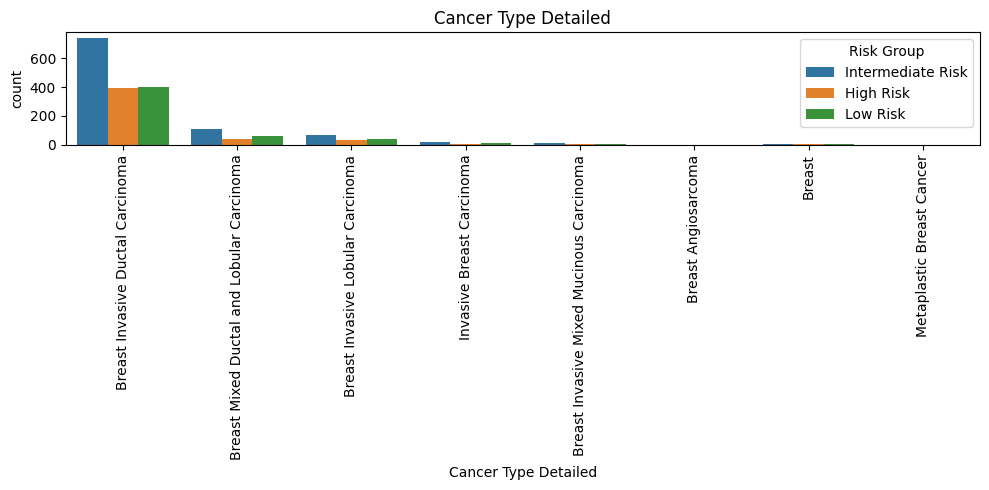

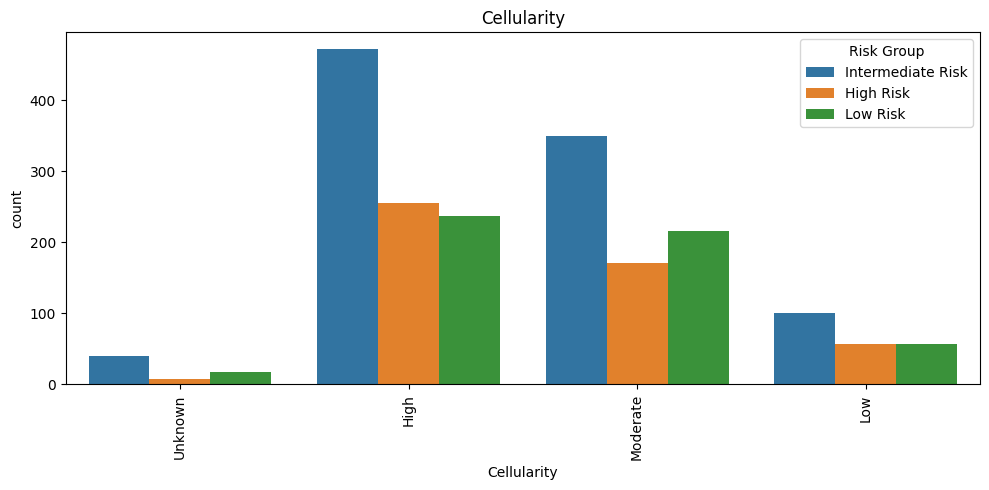

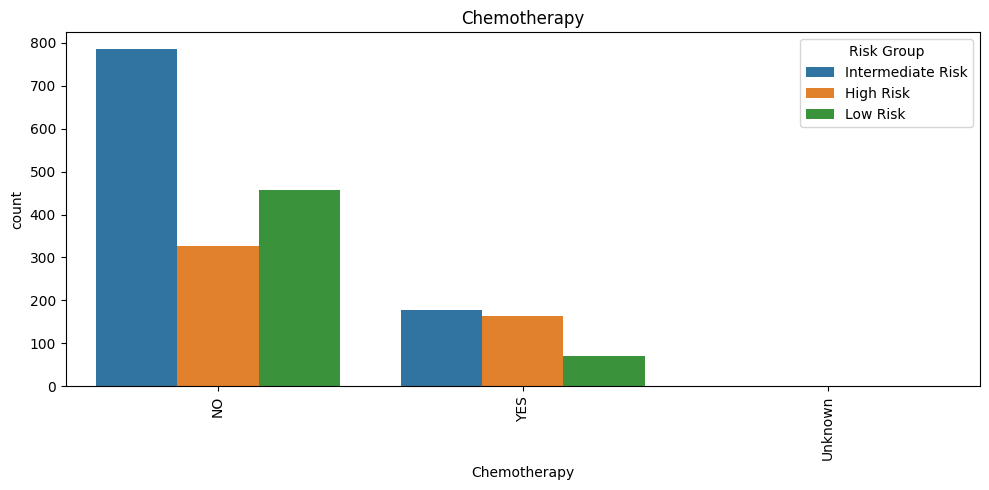

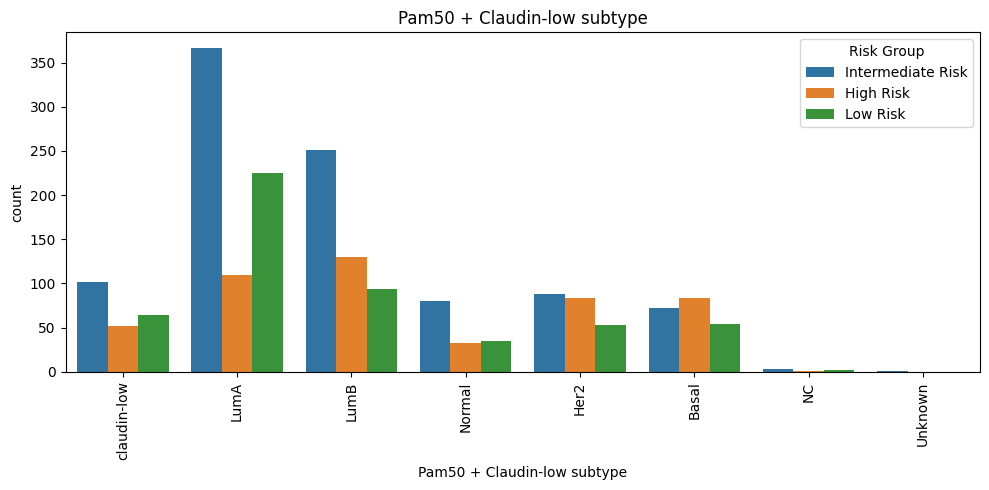

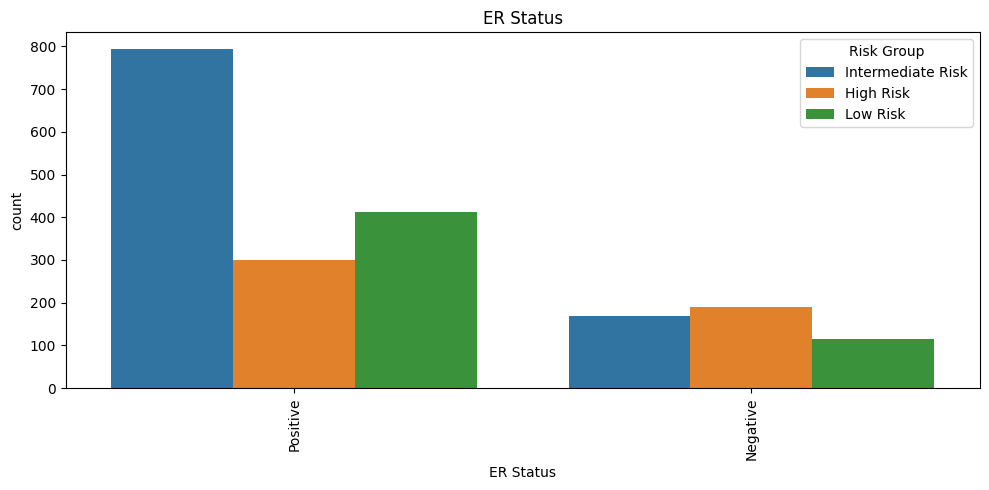

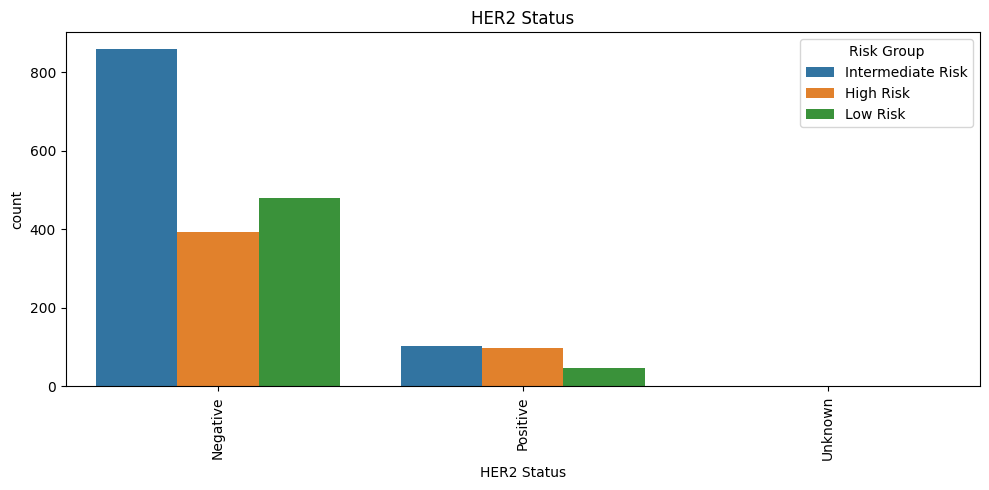

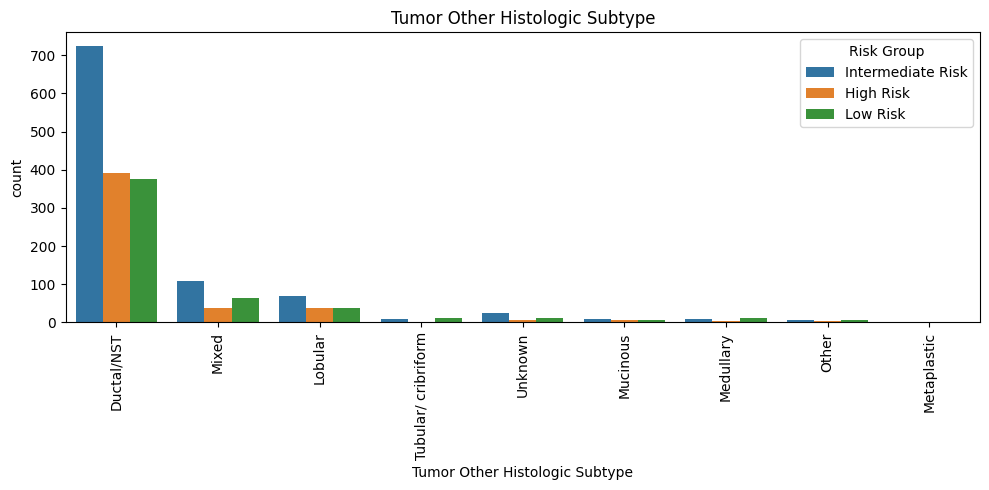

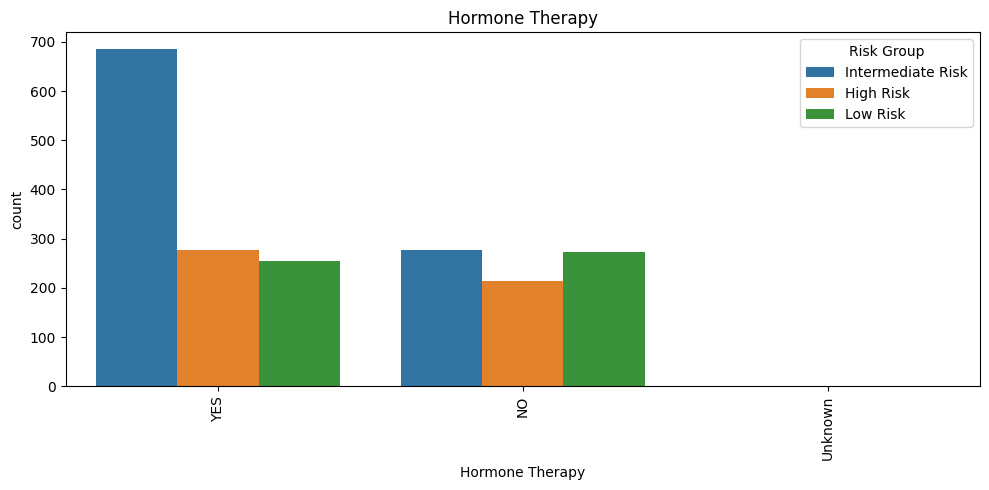

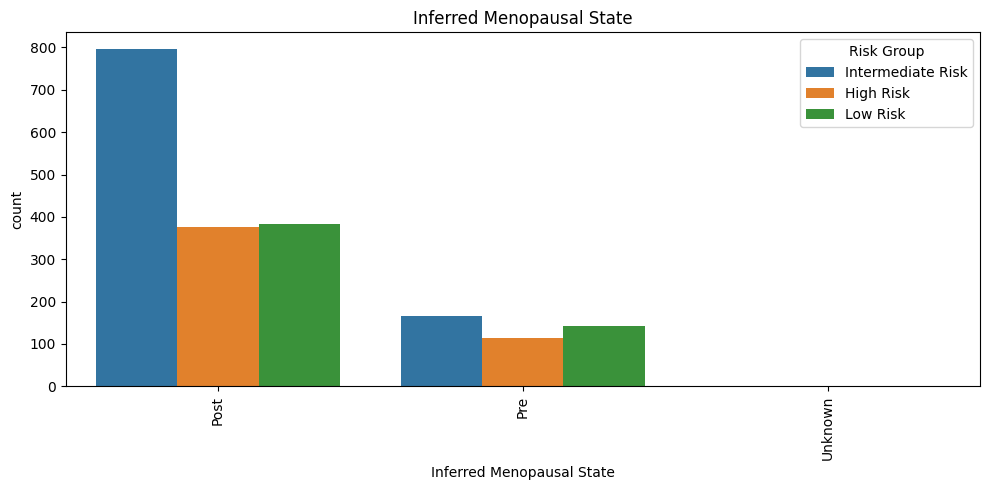

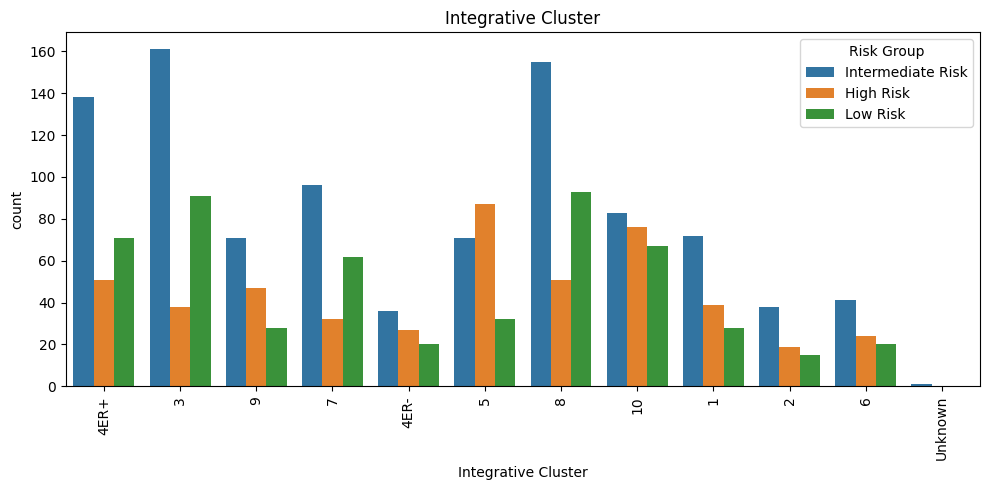

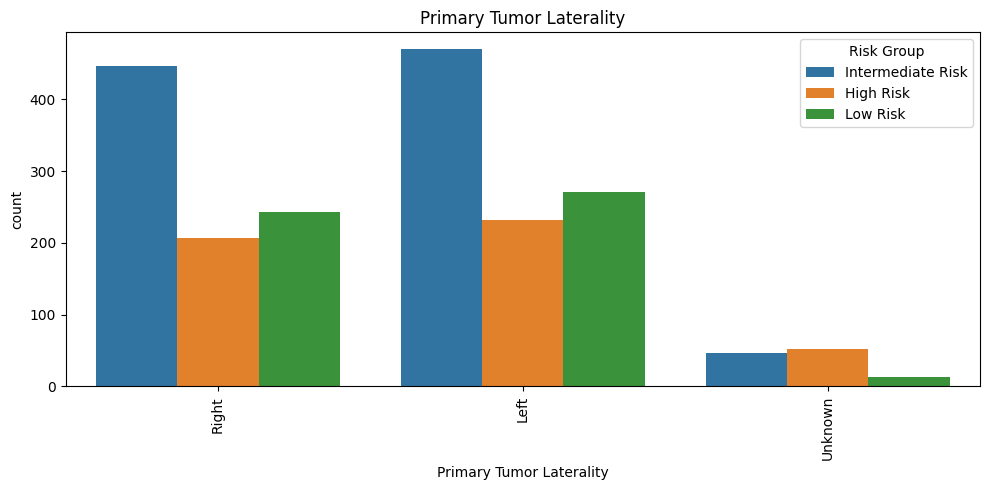

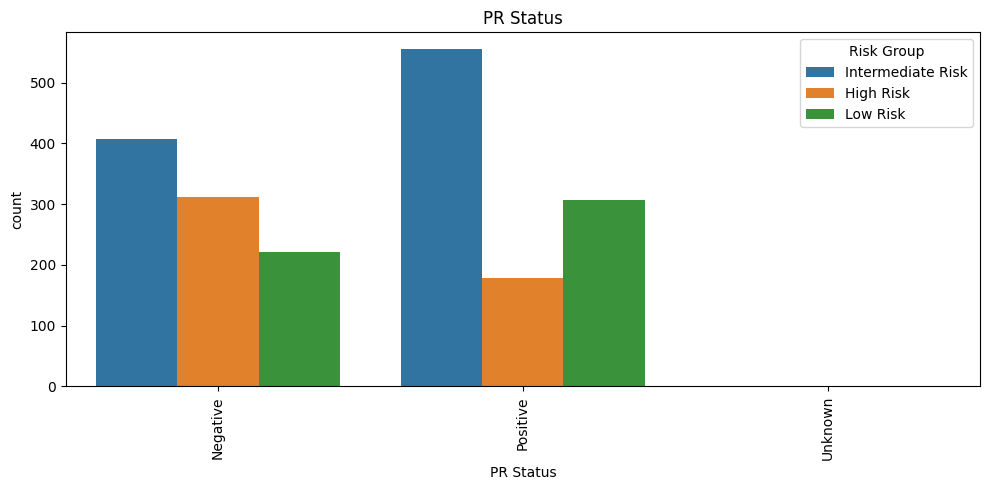

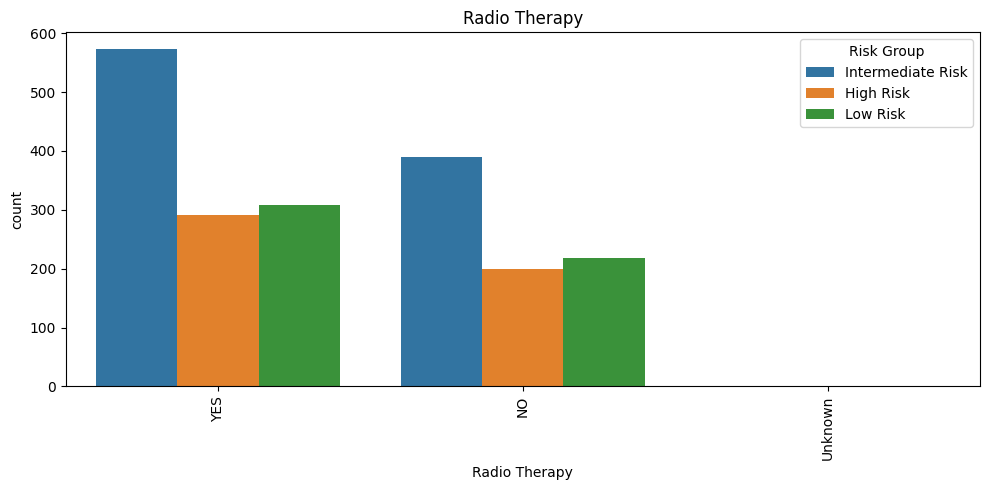

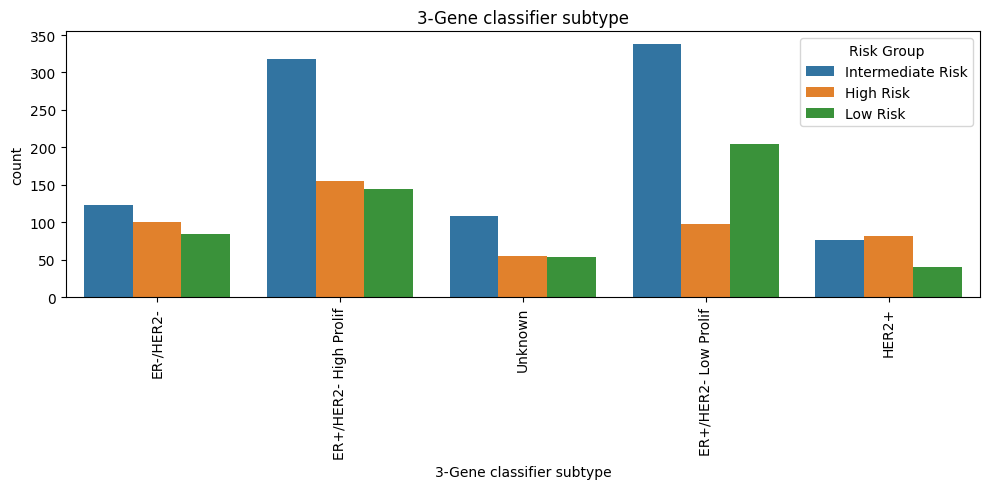

In [52]:
import seaborn as sns

categorical_features = [

    "Type of Breast Surgery",
    "Cancer Type Detailed",
    "Cellularity",
    "Chemotherapy",
    "Pam50 + Claudin-low subtype",
    "ER Status",
    "HER2 Status",
    "Tumor Other Histologic Subtype",
    "Hormone Therapy",
    "Inferred Menopausal State",
    "Integrative Cluster",
    "Primary Tumor Laterality",
    "PR Status",
    "Radio Therapy",
    "3-Gene classifier subtype"

]

for feature in categorical_features:

    plt.figure(figsize=(10,5))

    sns.countplot(
        data=model_df,
        x=feature,
        hue="Risk Group"
    )

    plt.xticks(rotation=90)

    plt.title(feature)

    plt.tight_layout()

    plt.show()

## 5.5 Statistical Comparison of Numerical Variables

## **Kruskal–Wallis Statistical Tests**
Since most clinical variables were not normally distributed, the non-parametric Kruskal–Wallis H test was used to compare the three clinical risk groups.

A significance level of α = 0.05 was adopted.

In [53]:
from scipy.stats import kruskal

results = []

for feature in numerical_features:

    low = model_df.loc[
        model_df["Risk Group"]=="Low Risk",
        feature
    ]

    intermediate = model_df.loc[
        model_df["Risk Group"]=="Intermediate Risk",
        feature
    ]

    high = model_df.loc[
        model_df["Risk Group"]=="High Risk",
        feature
    ]

    H,p = kruskal(
        low,
        intermediate,
        high
    )

    results.append([
        feature,
        H,
        p
    ])

results_df = pd.DataFrame(

    results,

    columns=[
        "Feature",
        "H Statistic",
        "P-value"
    ]

)

results_df["Significant"] = results_df["P-value"] < 0.05

results_df = results_df.sort_values(
    by="P-value"
)

display(results_df)

,Feature,H Statistic,P-value,Significant
5,Nottingham prognostic index,183.207967,1.647766e-40,True
4,Lymph nodes examined positive,133.503983,1.023242e-29,True
2,Tumor Stage,122.316749,2.749511e-27,True
1,Tumor Size,108.928295,2.220860e-24,True
0,Age at Diagnosis,59.359638,1.288898e-13,True
6,Neoplasm Histologic Grade,52.402572,4.177592e-12,True
7,TMB (nonsynonymous),14.300890,7.845148e-04,True
3,Mutation Count,13.432703,1.210948e-03,True


### 5.6 Ranking of Significant Variables

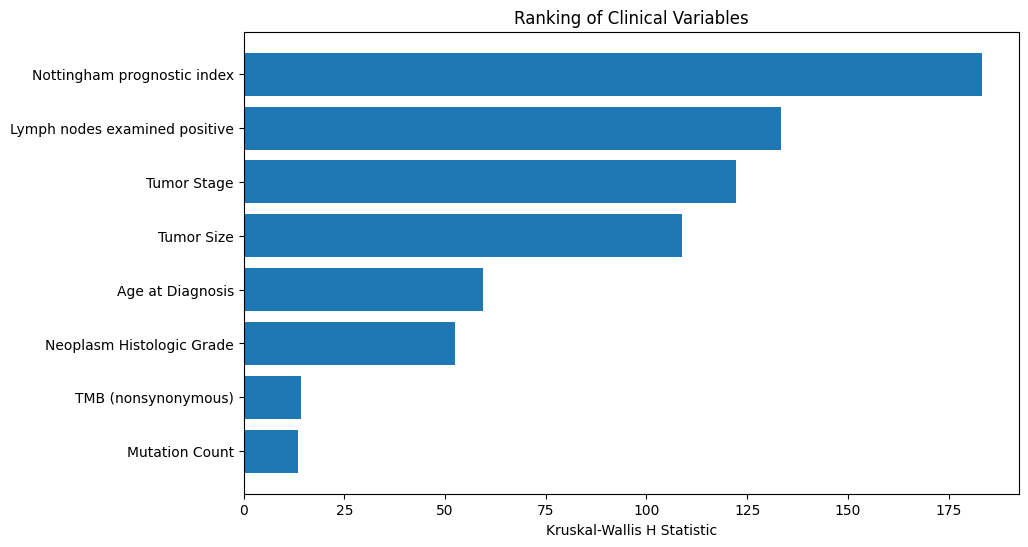

In [54]:
plt.figure(figsize=(10,6))

plt.barh(
    results_df["Feature"],
    results_df["H Statistic"]
)

plt.xlabel("Kruskal-Wallis H Statistic")

plt.title("Ranking of Clinical Variables")

plt.gca().invert_yaxis()

plt.show()

### CORRELATION HEATMAP

<Figure size 1200x1000 with 0 Axes>

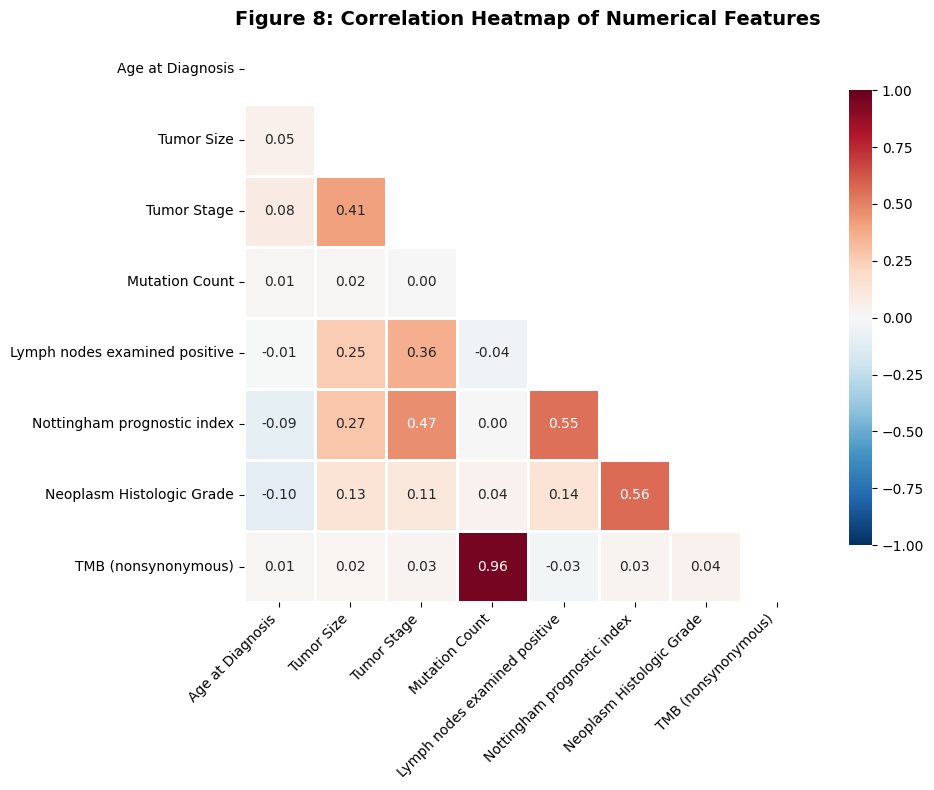


HIGH CORRELATION PAIRS (>0.7)
Mutation Count — TMB (nonsynonymous): 0.957


In [76]:
# ==========================================================
# FIGURE : CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(12, 10))

# Select numerical features
numerical_features = [
    "Age at Diagnosis",
    "Tumor Size",
    "Tumor Stage",
    "Mutation Count",
    "Lymph nodes examined positive",
    "Nottingham prognostic index",
    "Neoplasm Histologic Grade",
    "TMB (nonsynonymous)"
]

# Compute correlation matrix
corr_matrix = model_df[numerical_features].corr()

# Create heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=1,
    cbar_kws={"shrink": 0.8},
    vmin=-1,
    vmax=1
)

plt.title('Figure 8: Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print high correlation pairs
print("\n" + "="*60)
print("HIGH CORRELATION PAIRS (>0.7)")
print("="*60)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

for pair in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"{pair[0]} — {pair[1]}: {pair[2]:.3f}")

### FIGURE : DISTRIBUTION OF PAM50 SUBTYPES

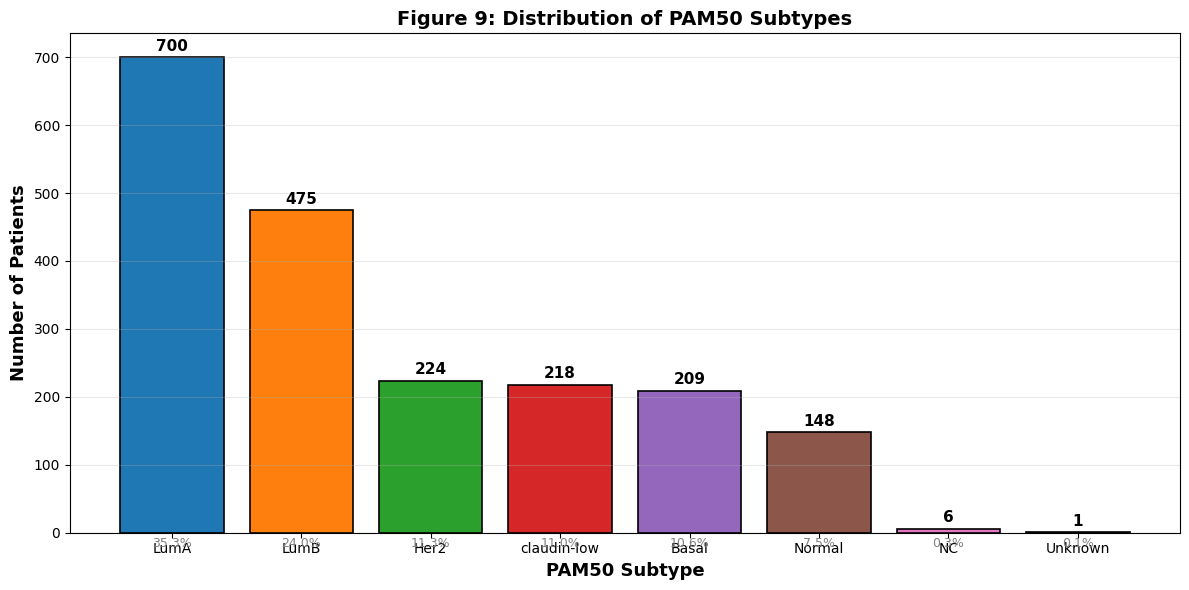


PAM50 SUBTYPE DISTRIBUTION
Pam50 + Claudin-low subtype
LumA           700
LumB           475
Her2           224
claudin-low    218
Basal          209
Normal         148
NC               6
Unknown          1
Name: count, dtype: int64

Total: 1981 patients


In [77]:
# ==========================================================
# FIGURE : DISTRIBUTION OF PAM50 SUBTYPES
# ==========================================================

plt.figure(figsize=(12, 6))

# Count PAM50 subtypes
pam50_counts = model_df["Pam50 + Claudin-low subtype"].value_counts()

# Define colors for each subtype
colors = {
    'LumA': '#1f77b4',
    'LumB': '#ff7f0e',
    'Her2': '#2ca02c',
    'claudin-low': '#d62728',
    'Basal': '#9467bd',
    'Normal': '#8c564b',
    'NC': '#e377c2'
}

# Bar chart
bars = plt.bar(
    pam50_counts.index,
    pam50_counts.values,
    color=[colors.get(subtype, 'gray') for subtype in pam50_counts.index],
    edgecolor='black',
    linewidth=1.2
)

for bar, count in zip(bars, pam50_counts.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 5,
        f'{count}',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

plt.xlabel('PAM50 Subtype', fontsize=13, fontweight='bold')
plt.ylabel('Number of Patients', fontsize=13, fontweight='bold')
plt.title('Figure 9: Distribution of PAM50 Subtypes', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Add percentage labels
for bar, (subtype, count) in zip(bars, pam50_counts.items()):
    pct = count / len(model_df) * 100
    plt.text(
        bar.get_x() + bar.get_width()/2,
        -25,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color='gray'
    )

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("PAM50 SUBTYPE DISTRIBUTION")
print("="*60)
print(pam50_counts)
print(f"\nTotal: {pam50_counts.sum()} patients")

FIGURE : MISSING VALUES HEATMAP

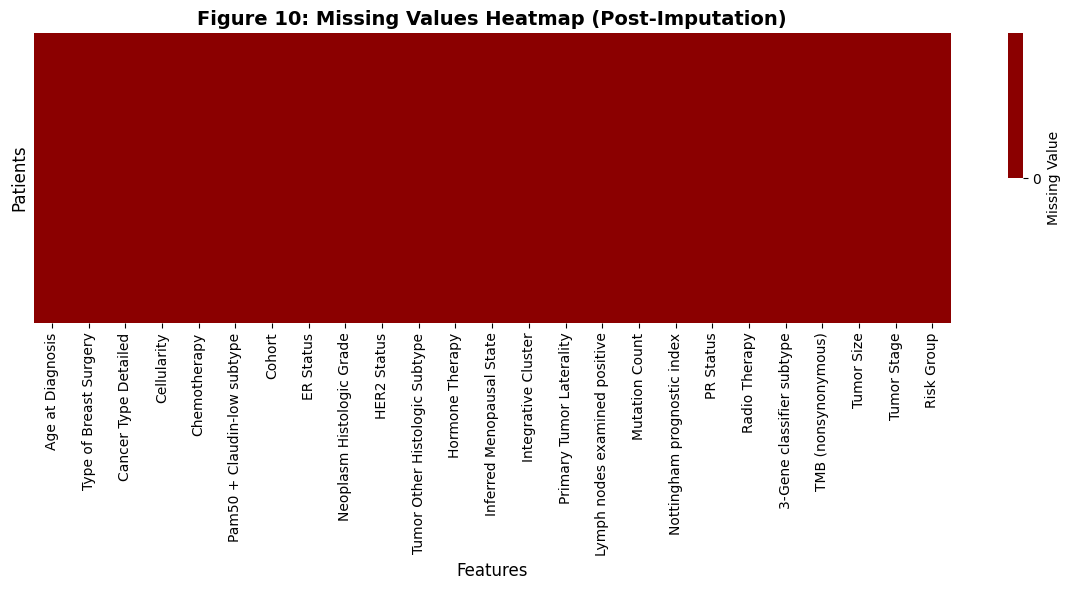


MISSING VALUES (POST-IMPUTATION)

✅ No missing values remain after imputation.


In [78]:
# ==========================================================
# FIGURE 10: MISSING VALUES HEATMAP
# ==========================================================

plt.figure(figsize=(12, 6))

# Create missing value matrix
missing_matrix = model_df.isnull()

# Create heatmap
sns.heatmap(
    missing_matrix,
    cbar=True,
    yticklabels=False,
    cmap=['white', 'darkred'],
    cbar_kws={'label': 'Missing Value', 'ticks': [0, 1]},
    xticklabels=True
)

plt.title('Figure 10: Missing Values Heatmap (Post-Imputation)', fontsize=14, fontweight='bold')
plt.xlabel('Features', fontsize=12)
plt.ylabel('Patients', fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("MISSING VALUES (POST-IMPUTATION)")
print("="*60)
missing_post = model_df.isnull().sum()
missing_post = missing_post[missing_post > 0]
if len(missing_post) == 0:
    print("\n✅ No missing values remain after imputation.")
else:
    print(missing_post)

## 5.7 Interpretation of Statistical Findings

The Kruskal–Wallis analysis demonstrated that all numerical variables differed significantly across the three clinical risk groups (p < 0.05).

The strongest prognostic variables were:

1. Nottingham Prognostic Index
2. Positive Lymph Nodes
3. Tumor Stage
4. Tumor Size
5. Age at Diagnosis

These findings are consistent with established breast cancer literature and provide clinical validation of the selected predictor variables.

Variables such as Mutation Count and Tumor Mutation Burden were statistically significant but exhibited smaller effect sizes, suggesting a comparatively weaker contribution to risk stratification.

### Create X and y

In [55]:
##########################################################
# STEP 7 : CREATE FEATURE MATRIX AND TARGET
##########################################################

X = model_df.drop(columns=["Risk Group"])

y = model_df["Risk Group"]

print("Feature Matrix :", X.shape)
print("Target :", y.shape)

print("\nTarget Distribution")
print(y.value_counts())

Feature Matrix : (1981, 24)
Target : (1981,)

Target Distribution
Risk Group
Intermediate Risk    963
Low Risk             527
High Risk            491
Name: count, dtype: int64


### Train/Test Split

In [56]:
##########################################################
# STEP 8 : TRAIN TEST SPLIT
##########################################################

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42

)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

print("\nTraining Distribution")
print(y_train.value_counts(normalize=True)*100)

print("\nTesting Distribution")
print(y_test.value_counts(normalize=True)*100)

Training Shape : (1584, 24)
Testing Shape : (397, 24)

Training Distribution
Risk Group
Intermediate Risk    48.611111
Low Risk             26.578283
High Risk            24.810606
Name: proportion, dtype: float64

Testing Distribution
Risk Group
Intermediate Risk    48.614610
Low Risk             26.700252
High Risk            24.685139
Name: proportion, dtype: float64


### Encode Target

In [57]:
##########################################################
# STEP 9 : LABEL ENCODE TARGET
##########################################################

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_encoded = label_encoder.fit_transform(y_train)

y_test_encoded = label_encoder.transform(y_test)

print(label_encoder.classes_)

print(label_encoder.classes_.shape)

print(dict(zip(

    label_encoder.classes_,

    label_encoder.transform(label_encoder.classes_)

)))

['High Risk' 'Intermediate Risk' 'Low Risk']
(3,)
{'High Risk': np.int64(0), 'Intermediate Risk': np.int64(1), 'Low Risk': np.int64(2)}


## Identify Numerical & Categorical Features

In [58]:
##########################################################
# STEP 10 : FEATURE TYPES
##########################################################

categorical_features = X_train.select_dtypes(

    include=["object"]

).columns.tolist()

numerical_features = X_train.select_dtypes(

    exclude=["object"]

).columns.tolist()

print("Categorical Features")
print(categorical_features)

print()

print("Numerical Features")
print(numerical_features)

Categorical Features
['Type of Breast Surgery', 'Cancer Type Detailed', 'Cellularity', 'Chemotherapy', 'Pam50 + Claudin-low subtype', 'ER Status', 'HER2 Status', 'Tumor Other Histologic Subtype', 'Hormone Therapy', 'Inferred Menopausal State', 'Integrative Cluster', 'Primary Tumor Laterality', 'PR Status', 'Radio Therapy', '3-Gene classifier subtype']

Numerical Features
['Age at Diagnosis', 'Cohort', 'Neoplasm Histologic Grade', 'Lymph nodes examined positive', 'Mutation Count', 'Nottingham prognostic index', 'TMB (nonsynonymous)', 'Tumor Size', 'Tumor Stage']


### 4 — One-Hot Encoding

In [59]:
##########################################################
# STEP 11 : ONE HOT ENCODING
##########################################################

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(

    transformers=[

        (

            "cat",

            OneHotEncoder(

                handle_unknown="ignore"

            ),

            categorical_features

        )

    ],

    remainder="passthrough"

)

X_train_encoded = preprocessor.fit_transform(X_train)

X_test_encoded = preprocessor.transform(X_test)

print(X_train_encoded.shape)

print(X_test_encoded.shape)

(1584, 73)
(397, 73)


### check fro NaNs

In [60]:
##########################################################
# STEP 12 : VERIFY NO MISSING VALUES
##########################################################

import numpy as np

print("NaNs in Train :", np.isnan(X_train_encoded).sum())

print("NaNs in Test :", np.isnan(X_test_encoded).sum())

NaNs in Train : 0
NaNs in Test : 0


## Standard Scaling (Only for Logistic Regression)

In [61]:
##########################################################
# STEP 13 : STANDARD SCALING
##########################################################

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train_encoded)

X_test_scaled = scaler.transform(X_test_encoded)

our outputs confirm:

- ✅ 1981 patients
- ✅ 24 predictor variables
- ✅ Stratified 80/20 train-test split
- ✅ 15 categorical + 9 numerical features
- ✅ One-hot encoding expanded the feature space from 24 to 73 features
- ✅ No missing values remain after preprocessing (NaNs in Train: 0, NaNs in Test: 0)

## 14A — Random Forest Feature Importance

In [62]:
############################################################
# STEP 14A : RANDOM FOREST FEATURE IMPORTANCE
############################################################

from sklearn.ensemble import RandomForestClassifier
import pandas as pd

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_encoded, y_train_encoded)

feature_names = preprocessor.get_feature_names_out()

rf_importance = pd.DataFrame({

    "Feature": feature_names,
    "Importance_RF": rf.feature_importances_

})

rf_importance = rf_importance.sort_values(
    by="Importance_RF",
    ascending=False
)

print("Total Features:", len(feature_names))

rf_importance.head(30)

Total Features: 73


,Feature,Importance_RF
64,remainder__Age at Diagnosis,0.092832
69,remainder__Nottingham prognostic index,0.087538
71,remainder__Tumor Size,0.071027
70,remainder__TMB (nonsynonymous),0.055307
68,remainder__Mutation Count,0.053753
65,remainder__Cohort,0.053297
67,remainder__Lymph nodes examined positive,0.044341
66,remainder__Neoplasm Histologic Grade,0.021639
72,remainder__Tumor Stage,0.020377
13,cat__Cellularity_Moderate,0.016760


## 14B — XGBoost Feature Importance

In [63]:
############################################################
# STEP 14B : XGBOOST FEATURE IMPORTANCE
############################################################

from xgboost import XGBClassifier

xgb = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=42

)

xgb.fit(

    X_train_encoded,

    y_train_encoded

)

xgb_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance_XGB": xgb.feature_importances_

})

xgb_importance = xgb_importance.sort_values(

    by="Importance_XGB",

    ascending=False

)

xgb_importance.head(30)

,Feature,Importance_XGB
65,remainder__Cohort,0.036856
72,remainder__Tumor Stage,0.028237
37,cat__Hormone Therapy_NO,0.027384
24,cat__ER Status_Negative,0.024753
51,cat__Integrative Cluster_9,0.023410
50,cat__Integrative Cluster_8,0.022994
54,cat__Primary Tumor Laterality_Unknown,0.022818
41,cat__Integrative Cluster_1,0.021729
46,cat__Integrative Cluster_4ER-,0.021106
69,remainder__Nottingham prognostic index,0.020919


## 14C — Combined Feature Importance

In [64]:
############################################################
# STEP 14C : COMBINED FEATURE IMPORTANCE
############################################################

importance_df = rf_importance.merge(

    xgb_importance,

    on="Feature"

)

importance_df["Average"] = (

    importance_df["Importance_RF"] +

    importance_df["Importance_XGB"]

)/2

importance_df = importance_df.sort_values(

    by="Average",

    ascending=False

).reset_index(drop=True)

importance_df.head(30)

,Feature,Importance_RF,Importance_XGB,Average
0,remainder__Age at Diagnosis,0.092832,0.018003,0.055417
1,remainder__Nottingham prognostic index,0.087538,0.020919,0.054229
2,remainder__Cohort,0.053297,0.036856,0.045076
3,remainder__Tumor Size,0.071027,0.016218,0.043622
4,remainder__TMB (nonsynonymous),0.055307,0.015399,0.035353
5,remainder__Mutation Count,0.053753,0.015631,0.034692
6,remainder__Lymph nodes examined positive,0.044341,0.020576,0.032458
7,remainder__Tumor Stage,0.020377,0.028237,0.024307
8,cat__Hormone Therapy_NO,0.013900,0.027384,0.020642
9,remainder__Neoplasm Histologic Grade,0.021639,0.018574,0.020107


**Interpretation of our feature importance**

The combined rankings show that the most influential predictors are:

| Rank | Feature                           | Clinical relevance                                          |
| ---- | --------------------------------- | ----------------------------------------------------------- |
| 1    | Age at Diagnosis                  | Strong prognostic factor in breast cancer                   |
| 2    | Nottingham Prognostic Index (NPI) | Established clinical prognostic index                       |
| 3    | Cohort                            | Dataset-specific variation (keep, but interpret cautiously) |
| 4    | Tumor Size                        | Major predictor of prognosis                                |
| 5    | TMB (Tumor Mutational Burden)     | Genomic biomarker                                           |
| 6    | Mutation Count                    | Genomic biomarker                                           |
| 7    | Positive Lymph Nodes              | Strong indicator of disease progression                     |
| 8    | Tumor Stage                       | Clinical staging variable                                   |
| 9    | Hormone Therapy                   | Treatment-related predictor                                 |
| 10   | Histologic Grade                  | Tumor aggressiveness                                        |


Cohort membership emerged as the third most important globally-ranked feature. Given that cohorts differ systematically in recruitment period and follow-up duration, this is interpreted as evidence that the target variable's dependence on unadjusted follow-up time propagates into the model's learned feature importances, rather than as evidence that recruitment batch has genuine prognostic value. Therefore, this variable was retained only to ensure methodological completeness, but its importance should not be interpreted clinically

## 1 — Random Forest Classification

In [65]:
############################################################
# STEP 15.1 : RANDOM FOREST CLASSIFIER
############################################################

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

rf_model = RandomForestClassifier(

    n_estimators=300,

    random_state=42,

    n_jobs=-1

)

rf_model.fit(
    X_train_encoded,
    y_train_encoded
)

rf_predictions = rf_model.predict(
    X_test_encoded
)

rf_accuracy = accuracy_score(
    y_test_encoded,
    rf_predictions
)

rf_precision = precision_score(
    y_test_encoded,
    rf_predictions,
    average="weighted"
)

rf_recall = recall_score(
    y_test_encoded,
    rf_predictions,
    average="weighted"
)

rf_f1 = f1_score(
    y_test_encoded,
    rf_predictions,
    average="weighted"
)

print("="*60)
print("Random Forest Results")
print("="*60)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

print("\nClassification Report\n")

print(

classification_report(

y_test_encoded,

rf_predictions,

target_names=label_encoder.classes_

)

)

Random Forest Results
Accuracy : 0.5642
Precision: 0.5581
Recall   : 0.5642
F1 Score : 0.5430

Classification Report

                   precision    recall  f1-score   support

        High Risk       0.55      0.36      0.43        98
Intermediate Risk       0.58      0.79      0.67       193
         Low Risk       0.54      0.35      0.42       106

         accuracy                           0.56       397
        macro avg       0.55      0.50      0.51       397
     weighted avg       0.56      0.56      0.54       397



## 2 — XGBoost Classification

In [66]:
############################################################
# STEP 15.2 : XGBOOST CLASSIFIER
############################################################

from xgboost import XGBClassifier

xgb_model = XGBClassifier(

    objective="multi:softprob",

    num_class=3,

    eval_metric="mlogloss",

    random_state=42

)

xgb_model.fit(
    X_train_encoded,
    y_train_encoded
)

xgb_predictions = xgb_model.predict(
    X_test_encoded
)

xgb_accuracy = accuracy_score(
    y_test_encoded,
    xgb_predictions
)

xgb_precision = precision_score(
    y_test_encoded,
    xgb_predictions,
    average="weighted"
)

xgb_recall = recall_score(
    y_test_encoded,
    xgb_predictions,
    average="weighted"
)

xgb_f1 = f1_score(
    y_test_encoded,
    xgb_predictions,
    average="weighted"
)

print("="*60)
print("XGBoost Results")
print("="*60)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")

print("\nClassification Report\n")

print(

classification_report(

y_test_encoded,

xgb_predictions,

target_names=label_encoder.classes_

)

)

XGBoost Results
Accuracy : 0.5264
Precision: 0.5183
Recall   : 0.5264
F1 Score : 0.5209

Classification Report

                   precision    recall  f1-score   support

        High Risk       0.46      0.41      0.43        98
Intermediate Risk       0.60      0.66      0.63       193
         Low Risk       0.43      0.39      0.41       106

         accuracy                           0.53       397
        macro avg       0.49      0.49      0.49       397
     weighted avg       0.52      0.53      0.52       397



## A — Logistic Regression

In [67]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

In [68]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

print("="*60)
print("Logistic Regression Results")
print("="*60)

lr = LogisticRegression(
    max_iter=3000,
    random_state=42
)

lr.fit(
    X_train_scaled,
    y_train_encoded
)

lr_pred = lr.predict(X_test_scaled)

lr_accuracy = accuracy_score(
    y_test_encoded,
    lr_pred
)

lr_precision = precision_score(
    y_test_encoded,
    lr_pred,
    average="weighted"
)

lr_recall = recall_score(
    y_test_encoded,
    lr_pred,
    average="weighted"
)

lr_f1 = f1_score(
    y_test_encoded,
    lr_pred,
    average="weighted"
)

print("Accuracy :", round(lr_accuracy,4))
print("Precision:", round(lr_precision,4))
print("Recall   :", round(lr_recall,4))
print("F1 Score :", round(lr_f1,4))

print("\nClassification Report\n")

print(
    classification_report(
        y_test_encoded,
        lr_pred,
        target_names=label_encoder.classes_
    )
)

Logistic Regression Results
Accuracy : 0.5466
Precision: 0.5392
Recall   : 0.5466
F1 Score : 0.5305

Classification Report

                   precision    recall  f1-score   support

        High Risk       0.58      0.43      0.49        98
Intermediate Risk       0.56      0.74      0.64       193
         Low Risk       0.46      0.31      0.37       106

         accuracy                           0.55       397
        macro avg       0.53      0.49      0.50       397
     weighted avg       0.54      0.55      0.53       397



## B — LightGBM

In [69]:
!pip install lightgbm -q

In [70]:
from lightgbm import LGBMClassifier

print("="*60)
print("LightGBM Results")
print("="*60)

lgb = LGBMClassifier(
    random_state=42
)

lgb.fit(
    X_train_encoded,
    y_train_encoded
)

lgb_pred = lgb.predict(
    X_test_encoded
)

lgb_accuracy = accuracy_score(
    y_test_encoded,
    lgb_pred
)

lgb_precision = precision_score(
    y_test_encoded,
    lgb_pred,
    average="weighted"
)

lgb_recall = recall_score(
    y_test_encoded,
    lgb_pred,
    average="weighted"
)

lgb_f1 = f1_score(
    y_test_encoded,
    lgb_pred,
    average="weighted"
)

print("Accuracy :", round(lgb_accuracy,4))
print("Precision:", round(lgb_precision,4))
print("Recall   :", round(lgb_recall,4))
print("F1 Score :", round(lgb_f1,4))

print("\nClassification Report\n")

print(
    classification_report(
        y_test_encoded,
        lgb_pred,
        target_names=label_encoder.classes_
    )
)

LightGBM Results
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000844 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 734
[LightGBM] [Info] Number of data points in the train set: 1584, number of used features: 65
[LightGBM] [Info] Start training from score -1.393899
[LightGBM] [Info] Start training from score -0.721318
[LightGBM] [Info] Start training from score -1.325076
Accuracy : 0.5315
Precision: 0.5267
Recall   : 0.5315
F1 Score : 0.5271

Classification Report

                   precision    recall  f1-score   support

        High Risk       0.52      0.45      0.48        98
Intermediate Risk       0.57      0.64      0.60       193
         Low Risk       0.45      0.41      0.43       106

         accuracy                           0.53       397
        macro avg       0.51      0.50      0.50       397
     weighted avg 

## C — CatBoost

In [71]:
!pip install catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 7.9 MB/s eta 0:00:00


In [72]:
from catboost import CatBoostClassifier

print("="*60)
print("CatBoost Results")
print("="*60)

cat = CatBoostClassifier(
    verbose=0,
    random_state=42
)

cat.fit(
    X_train_encoded,
    y_train_encoded
)

cat_pred = cat.predict(
    X_test_encoded
)

cat_accuracy = accuracy_score(
    y_test_encoded,
    cat_pred
)

cat_precision = precision_score(
    y_test_encoded,
    cat_pred,
    average="weighted"
)

cat_recall = recall_score(
    y_test_encoded,
    cat_pred,
    average="weighted"
)

cat_f1 = f1_score(
    y_test_encoded,
    cat_pred,
    average="weighted"
)

print("Accuracy :", round(cat_accuracy,4))
print("Precision:", round(cat_precision,4))
print("Recall   :", round(cat_recall,4))
print("F1 Score :", round(cat_f1,4))

print("\nClassification Report\n")

print(
    classification_report(
        y_test_encoded,
        cat_pred,
        target_names=label_encoder.classes_
    )
)

CatBoost Results
Accuracy : 0.5441
Precision: 0.5391
Recall   : 0.5441
F1 Score : 0.5385

Classification Report

                   precision    recall  f1-score   support

        High Risk       0.52      0.42      0.46        98
Intermediate Risk       0.58      0.66      0.62       193
         Low Risk       0.49      0.44      0.47       106

         accuracy                           0.54       397
        macro avg       0.53      0.51      0.52       397
     weighted avg       0.54      0.54      0.54       397



## 13 — Compare All Five Models

In [73]:
comparison = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost",
        "Logistic Regression",
        "LightGBM",
        "CatBoost"
    ],

    "Accuracy":[
        rf_accuracy,
        xgb_accuracy,
        lr_accuracy,
        lgb_accuracy,
        cat_accuracy
    ],

    "Precision":[
        rf_precision,
        xgb_precision,
        lr_precision,
        lgb_precision,
        cat_precision
    ],

    "Recall":[
        rf_recall,
        xgb_recall,
        lr_recall,
        lgb_recall,
        cat_recall
    ],

    "F1 Score":[
        rf_f1,
        xgb_f1,
        lr_f1,
        lgb_f1,
        cat_f1
    ]

})

comparison = comparison.sort_values(
    "Accuracy",
    ascending=False
)

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.564232,0.558074,0.564232,0.542956
2,Logistic Regression,0.546599,0.539229,0.546599,0.530538
4,CatBoost,0.544081,0.539133,0.544081,0.538497
3,LightGBM,0.531486,0.526696,0.531486,0.527090
1,XGBoost,0.526448,0.518306,0.526448,0.520916


## Confusion Matrix

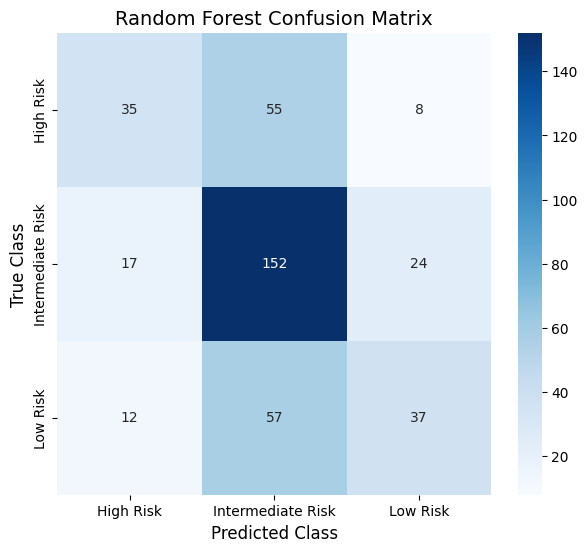

In [74]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predictions
rf_predictions = rf_model.predict(X_test_encoded)

# Confusion Matrix
cm = confusion_matrix(
    y_test_encoded,
    rf_predictions
)

plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted Class", fontsize=12)
plt.ylabel("True Class", fontsize=12)
plt.title("Random Forest Confusion Matrix", fontsize=14)

plt.show()

In [75]:
cm_df = pd.DataFrame(
    cm,
    index=label_encoder.classes_,
    columns=label_encoder.classes_
)

display(cm_df)

,High Risk,Intermediate Risk,Low Risk
High Risk,35,55,8
Intermediate Risk,17,152,24
Low Risk,12,57,37


## Key Results Summary

### Model Performance Comparison

| Model                  | Accuracy | Precision | Recall | F1 Score |
|-------------------------|---------:|----------:|--------:|---------:|
| Random Forest           | **56.42%** | **55.81%** | **56.42%** | **54.30%** |
| Logistic Regression     | 54.66% | 53.92% | 54.66% | 53.05% |
| CatBoost                | 54.41% | 53.91% | 54.41% | 53.85% |
| LightGBM                | 53.15% | 52.67% | 53.15% | 52.71% |
| XGBoost                 | 52.64% | 51.83% | 52.64% | 52.09% |

### Key Findings

- **Random Forest** achieved the best overall performance across all evaluated models.
- It recorded the highest **Accuracy (56.42%)**, **Precision (55.81%)**, **Recall (56.42%)**, and **F1 Score (54.30%)**.
- The model correctly identified **152 out of 193 Intermediate Risk patients**, demonstrating superior predictive capability compared to the other machine learning models evaluated.
- Although the performance differences among the models were relatively small, **Random Forest consistently outperformed** Logistic Regression, CatBoost, LightGBM, and XGBoost, making it the preferred model for this classification task.

## Pending Tasks

### Model Development & Optimization
- Hyperparameter optimization using **RandomizedSearchCV** and **Optuna**
- Implement ensemble learning techniques:
  - Soft Voting
  - Stacking
- Address class imbalance using:
  - SMOTE (Synthetic Minority Oversampling Technique)
  - Class-weighted models

### Explainable AI (XAI)
- Generate **SHAP** global feature importance explanations
- Generate **SHAP** local explanations for individual predictions

### Clinical Model Enhancement
- Implement cost-sensitive learning
- Perform decision threshold optimization
- Develop a two-stage hierarchical prediction model

### Error Analysis
- Analyse high-risk patient predictions
- Compare **True Positives (TP)** and **False Negatives (FN)** to identify failure patterns and potential areas for improvement

### Clinical Demonstration
- Prepare a clinician-facing demonstration
- Provide prediction explanations in clear, plain language suitable for healthcare professionals

### Documentation & Results
- Finalise project documentation and code annotations
- Prepare final results tables, figures, and visualisations

### Report & Submission
- Complete the final project report
- Review, proofread, and submit all project deliverables